### Bibliotecas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from IPython.display import Image
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from functools import reduce
import pickle
import warnings
warnings.filterwarnings("ignore")

### Importación de Datos

In [ ]:
# Importar datos y crear un DataFrame
df = pd.read_csv('/content/drive/MyDrive/Projeto_Clusterização/marketing_campaign.csv', delimiter='\t')

In [ ]:
print("Formato del DataFrame: ", df.shape)
df.head()

Formato del DataFrame:  (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Análisis Exploratorio de Datos y Limpieza

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

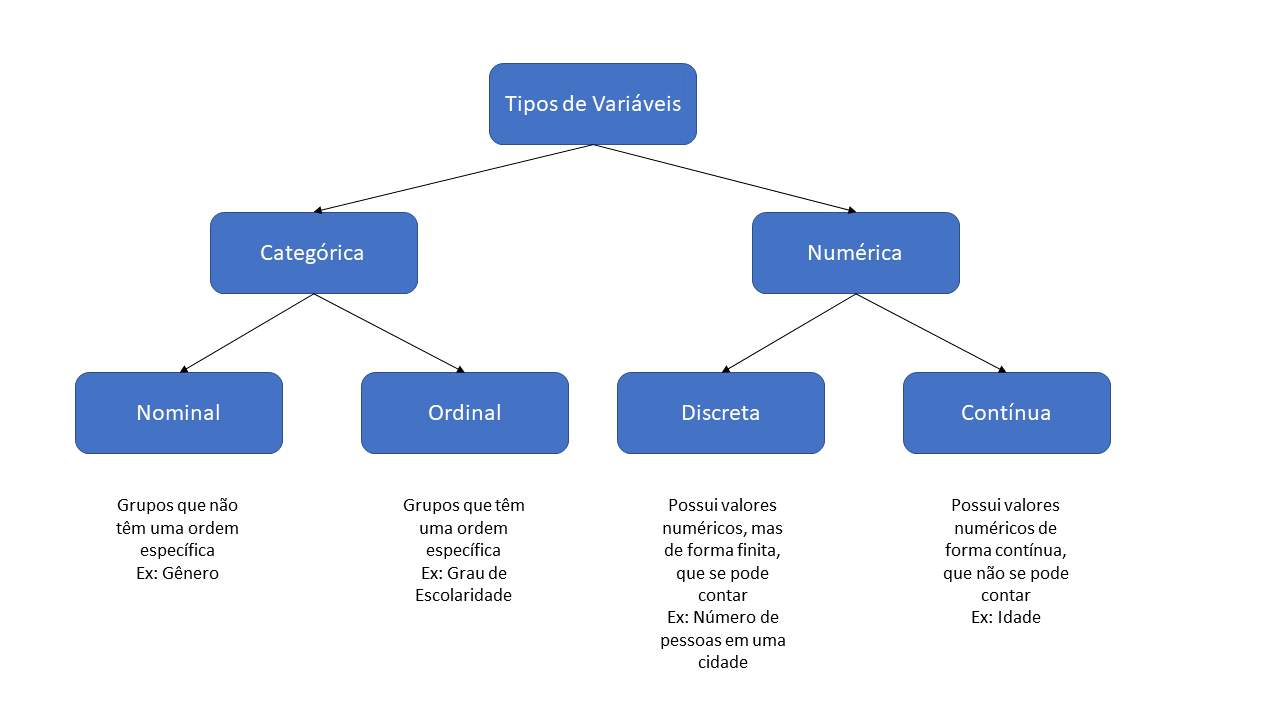

In [ ]:
Image(filename='/content/drive/MyDrive/Projeto_Clusterização/Tipos+de+Variáveis.png', width=1000, height=1000)

In [ ]:
# Visualizar los valores nulos de un DataFrame
def show_null(df):
    null_columns = (df.isnull().sum(axis=0)/len(df)).sort_values(ascending=False).index

    null_data = pd.concat([df.isnull().sum(axis=0),
                           (df.isnull().sum(axis=0)/len(df)).sort_values(ascending=False),
                           df.loc[:, df.columns.isin(list(null_columns))].dtypes],
                          axis=1)

    null_data = null_data.rename(columns={0: '#',
                                          1: '% null',
                                          2: 'type'}).sort_values(ascending=False,
                                                                  by='% null')

    return null_data

In [ ]:
# Generar un gráfico de variables numéricas
def plot_num(df, feature):
    fig = plt.figure(figsize=(12,8))
    gs = GridSpec(1,2)
    sns.boxplot(y=feature, data=df, color='firebrick', ax=fig.add_subplot(gs[0,0]))
    plt.ylabel(feature)
    sns.stripplot(y=df[feature], color='darkcyan', ax=fig.add_subplot(gs[0,1]))
    plt.ylabel(None)
    plt.show()

In [ ]:
# Generar un gráfico de variables categóricas
def plot_cat(df, feature):
    fig = plt.figure(figsize=(12,8))
    ax = sns.countplot(data=df, x=feature)
    for p in ax.patches:

        ax.annotate(f'\n{p.get_height()}',
                    (p.get_x()+0.4, p.get_height()+5),
                    ha='center',
                    color='black')

    plt.xlabel('\n' + feature)
    plt.ylabel('Quantidade de Clientes')
    plt.show()

#### People

In [ ]:
# Caracteristicas de la personas
people = df[['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
             'Recency', 'Complain']]

In [ ]:
people.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0


In [ ]:
# verifivar valores nulos
show_null(people)

,#,% null,type
Income,24,0.010714,float64
ID,0,0.000000,int64
Year_Birth,0,0.000000,int64
Education,0,0.000000,object
Marital_Status,0,0.000000,object
Kidhome,0,0.000000,int64
Teenhome,0,0.000000,int64
Dt_Customer,0,0.000000,object
Recency,0,0.000000,int64
Complain,0,0.000000,int64


##### Income

In [ ]:
# Vamos dropar Income
people.dropna(inplace=True)

In [ ]:
# verifivar valores nulos
show_null(people)

,#,% null,type
ID,0,0.0,int64
Year_Birth,0,0.0,int64
Education,0,0.0,object
Marital_Status,0,0.0,object
Income,0,0.0,float64
Kidhome,0,0.0,int64
Teenhome,0,0.0,int64
Dt_Customer,0,0.0,object
Recency,0,0.0,int64
Complain,0,0.0,int64


Despues de dropar la columna Income, se que seque todo sin valores nulos.

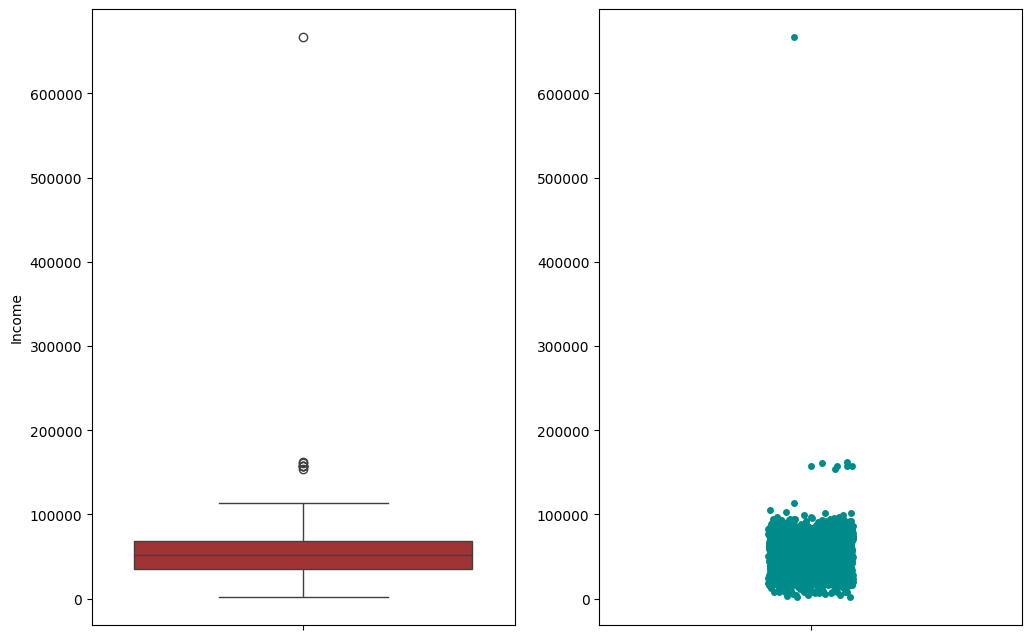

In [ ]:
# Comprobar si hay outliers
plot_num(people, 'Income')

In [ ]:
# Eliminar outliers superiores 200000
people = people[people.Income < 200000]

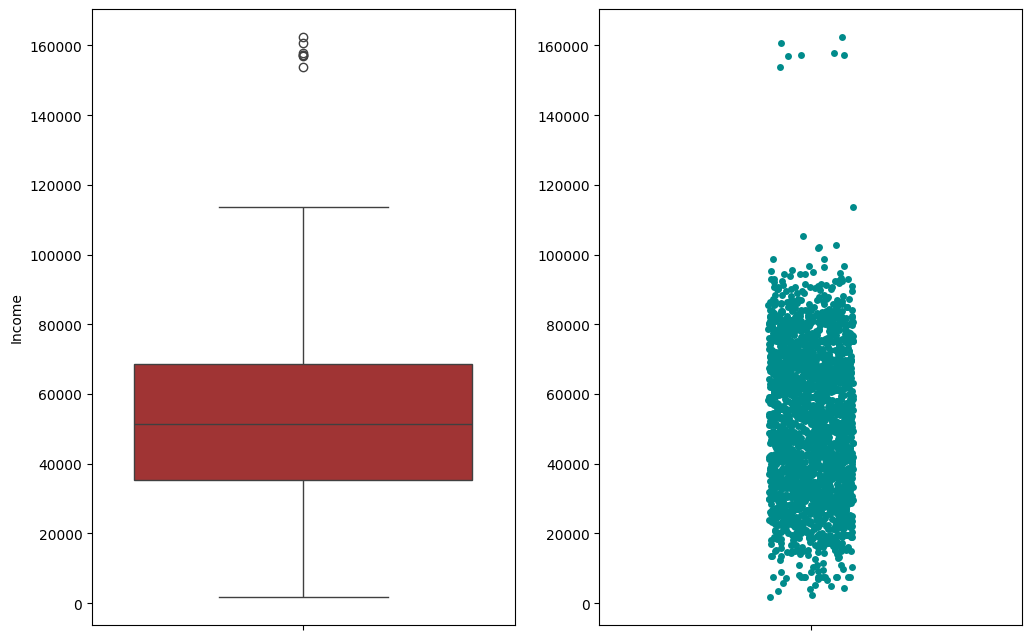

In [ ]:
plot_num(people, 'Income')

##### Year_Birth

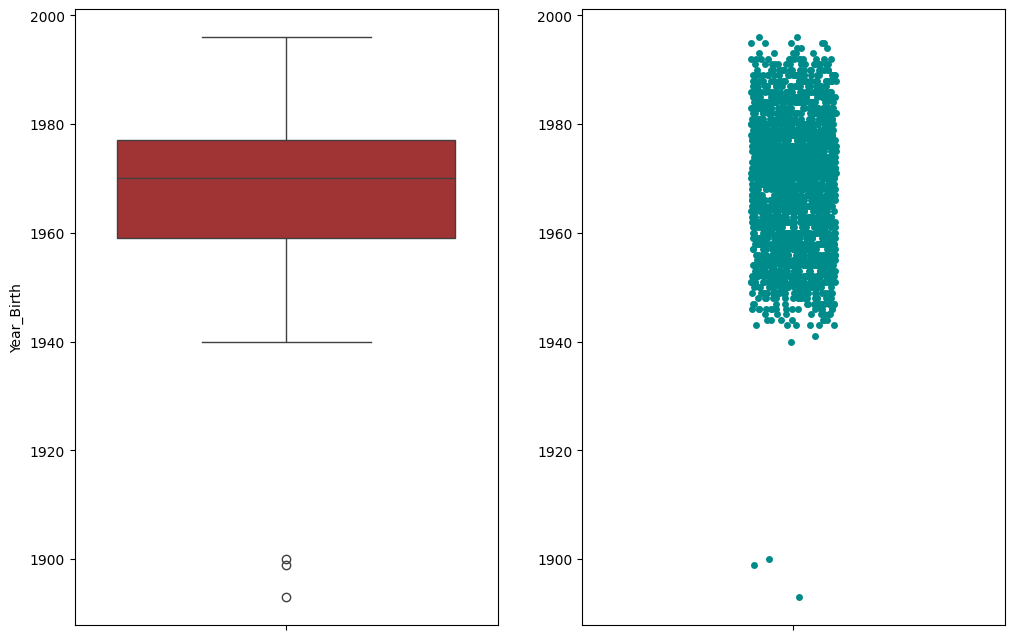

In [ ]:
# Comprobar si hay outliers
plot_num(people, 'Year_Birth')

In [ ]:
# Vamos eliminar la edad una vez que no hay personas antes de 1900
people = people[people.Year_Birth > 1930]

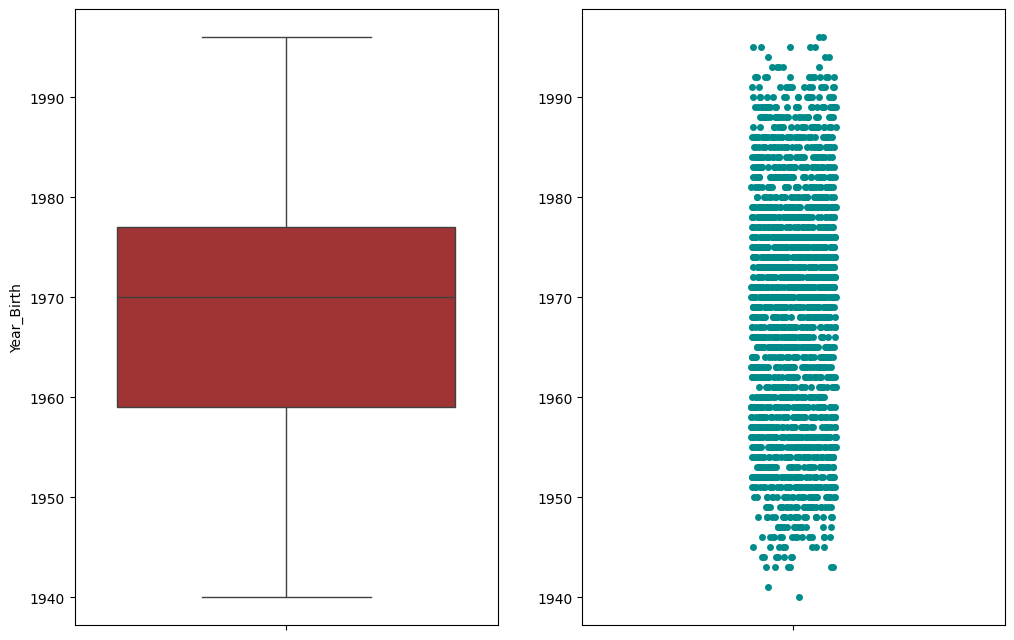

In [ ]:
plot_num(people, 'Year_Birth')

##### Education

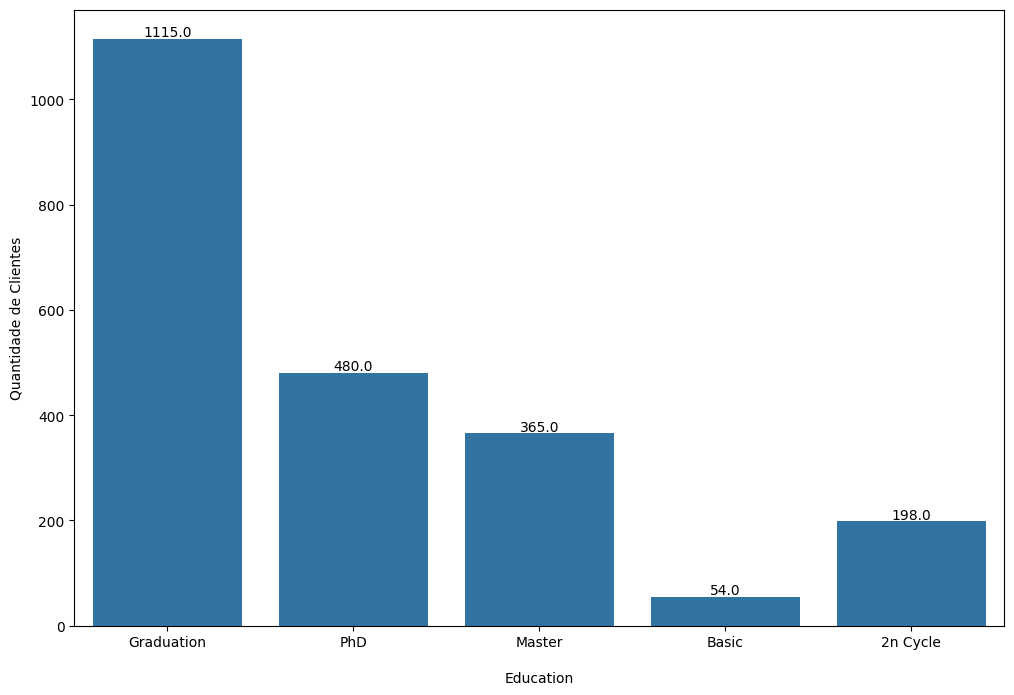

In [ ]:
# Ver a cuantidade de personas por educacion
plot_cat(people, 'Education')

In [ ]:
# Transformar los valores de la columna Education (categórica) en una columna numérica
people.Education = people.Education.apply(lambda x: 0 if x=='Basic'
                       else(1 if x=='2n Cycle'
                            else(2 if x=='Graduation'
                                 else(3 if x =='Master'
                                      else(4 if x=='PhD' else None)))))

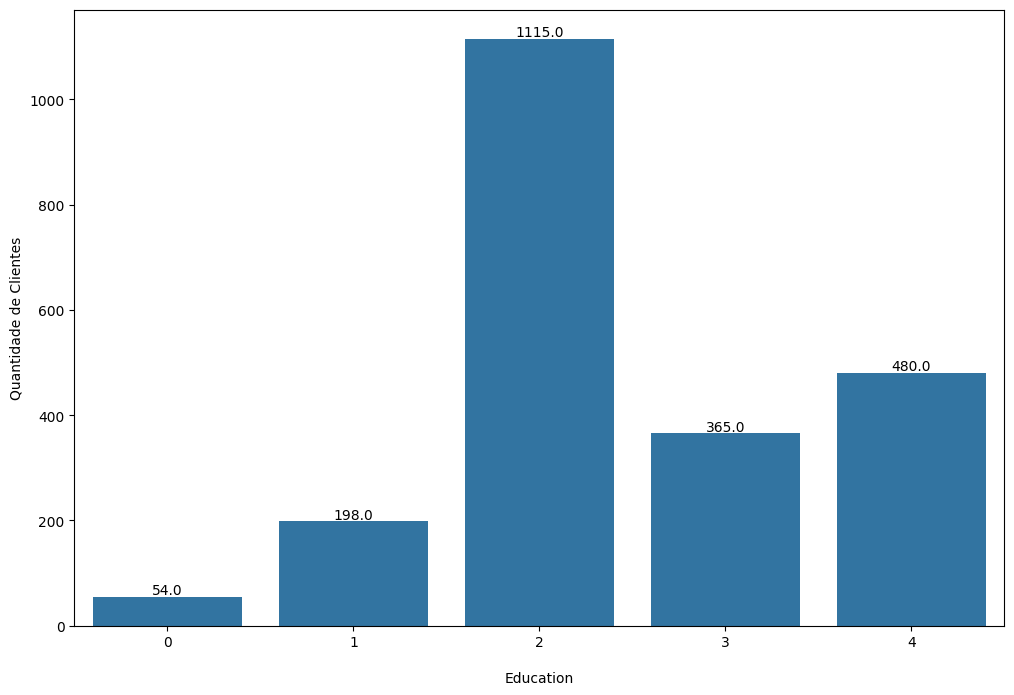

In [ ]:
plot_cat(people, 'Education')

##### Marital_Status

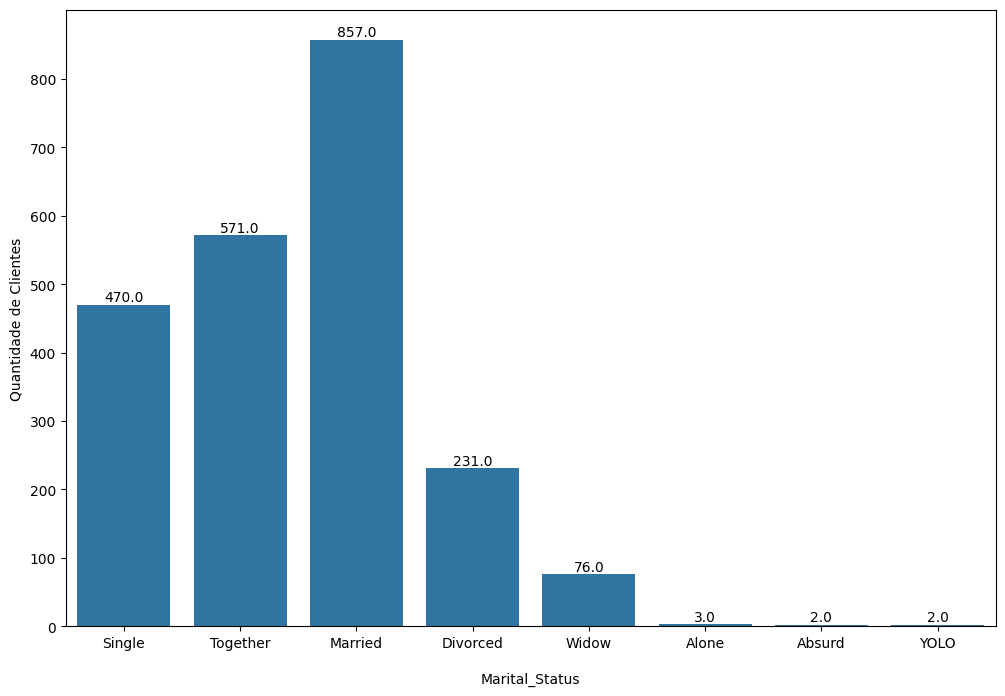

In [ ]:
plot_cat(people, 'Marital_Status')

In [ ]:
people = people[people.Marital_Status != 'Absurd']

In [ ]:
# Asignamos "Alone" y "YOLO" a la columna "single"
people.Marital_Status = people.Marital_Status.apply(lambda x: 'Single' if x=='Alone'
                                                    else('Single' if x =='YOLO' else x))

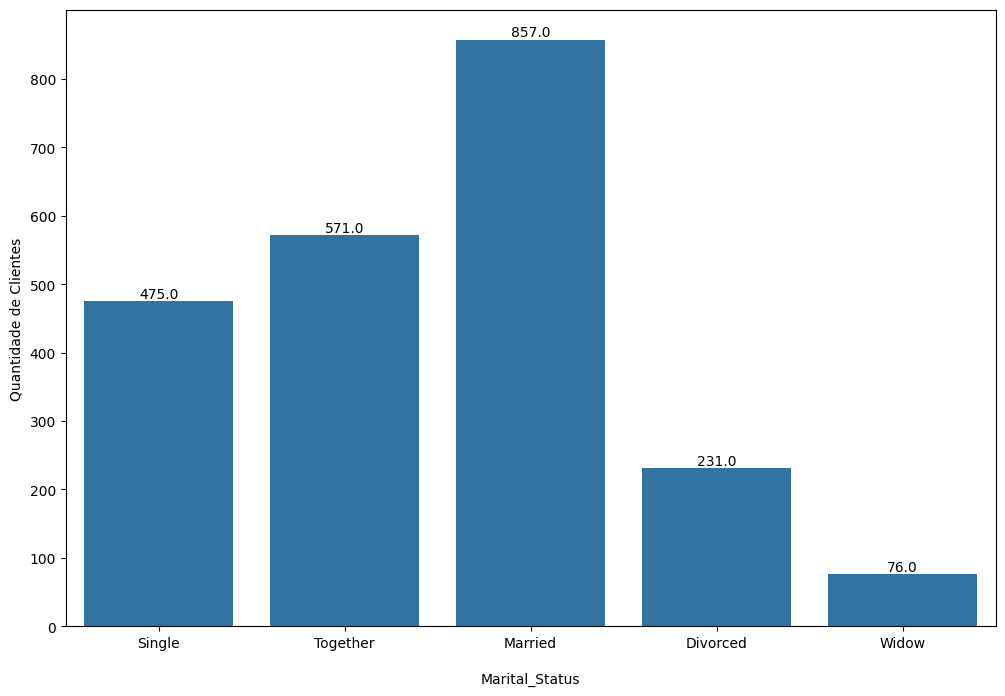

In [ ]:
plot_cat(people, 'Marital_Status')

In [ ]:
# Asignamos "Together"  a la columna "Married"
people.Marital_Status = people.Marital_Status.apply(lambda x: 'Together' if x=='Married' else x)

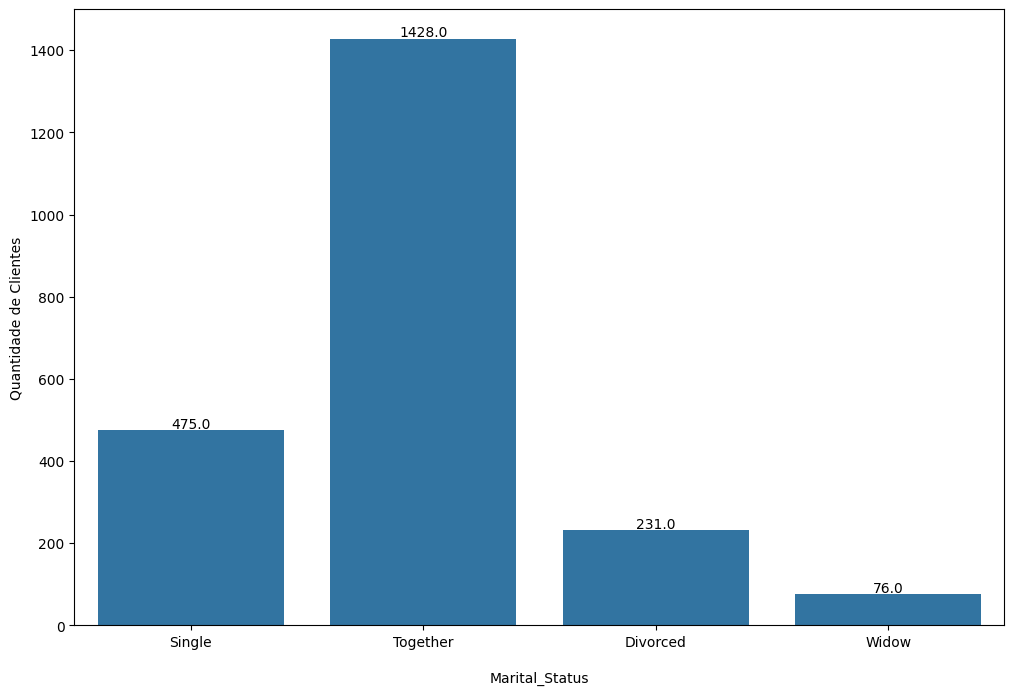

In [ ]:
plot_cat(people, 'Marital_Status')

In [ ]:
people.dtypes

,0
ID,int64
Year_Birth,int64
Education,int64
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
Complain,int64


In [ ]:
people.Dt_Customer = pd.to_datetime(people.Dt_Customer, dayfirst=True)

In [ ]:
# Convertir variables categóricas (nominales u ordinales) a variables numéricas
people = pd.get_dummies(people).astype(int)

In [ ]:
people

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,1957,2,58138,0,0,1346716800000000000,58,0,0,1,0,0
1,2174,1954,2,46344,1,1,1394236800000000000,38,0,0,1,0,0
2,4141,1965,2,71613,0,0,1377043200000000000,26,0,0,0,1,0
3,6182,1984,2,26646,1,0,1391990400000000000,26,0,0,0,1,0
4,5324,1981,4,58293,1,0,1390089600000000000,94,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,2,61223,0,1,1371081600000000000,46,0,0,0,1,0
2236,4001,1946,4,64014,2,1,1402358400000000000,56,0,0,0,1,0
2237,7270,1981,2,56981,0,0,1390608000000000000,91,0,1,0,0,0
2238,8235,1956,3,69245,0,1,1390521600000000000,8,0,0,0,1,0


##### Kidhome

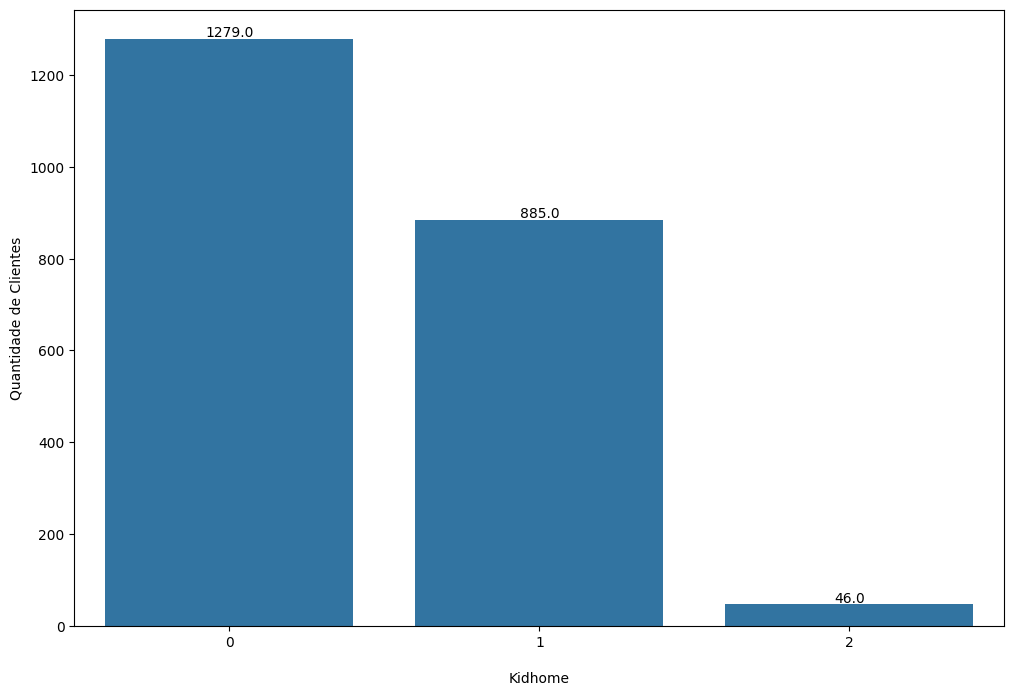

In [ ]:
plot_cat(people, 'Kidhome')

##### TeenHome

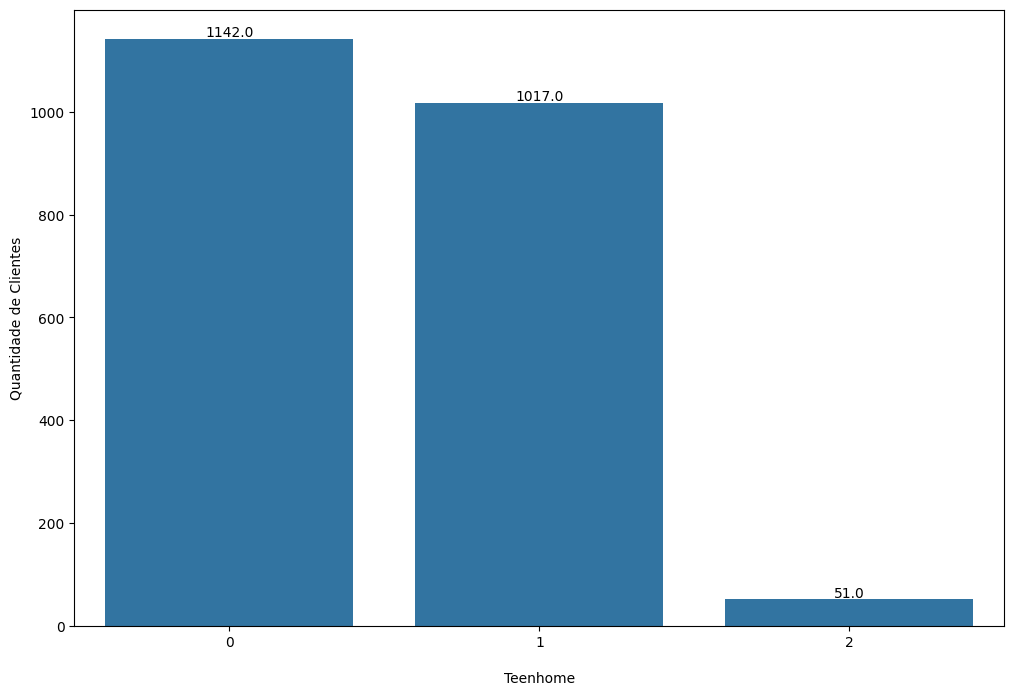

In [ ]:
plot_cat(people, 'Teenhome')

##### ChildrenHome

In [ ]:
# Vamos a combinar las columnas 'Kidhome' y 'Teenhome' porque todos viven en casa con sus padres.
people['ChildrenHome'] = people.Kidhome + people.Teenhome

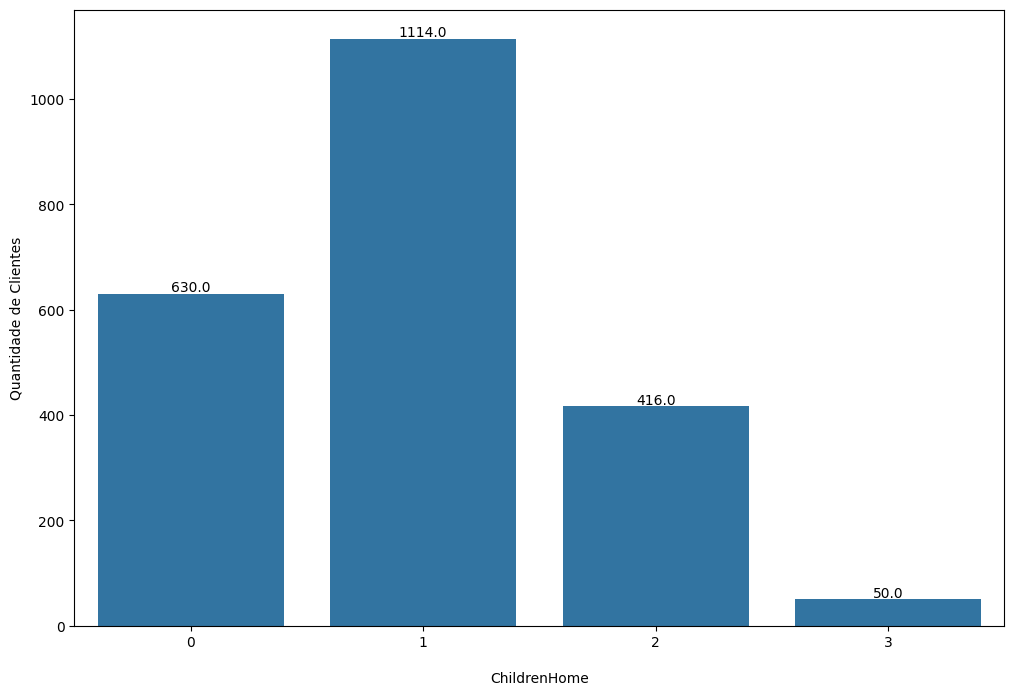

In [ ]:
plot_cat(people, 'ChildrenHome')

In [ ]:
# Eliminar las columnas 'Kidhome' y 'Teenhome'
people.drop(columns=['Kidhome', 'Teenhome'], inplace=True)

In [ ]:
people.head()

,ID,Year_Birth,Education,Income,Dt_Customer,Recency,Complain,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome
0,5524,1957,2,58138,1346716800000000000,58,0,0,1,0,0,0
1,2174,1954,2,46344,1394236800000000000,38,0,0,1,0,0,2
2,4141,1965,2,71613,1377043200000000000,26,0,0,0,1,0,0
3,6182,1984,2,26646,1391990400000000000,26,0,0,0,1,0,1
4,5324,1981,4,58293,1390089600000000000,94,0,0,0,1,0,1


##### Dt_Customer


Vamos calcular max y min con referencia de las fechas

In [ ]:
people.Dt_Customer = pd.to_datetime(people.Dt_Customer, dayfirst=True)

In [ ]:
people.Dt_Customer.min()

Timestamp('2012-07-30 00:00:00')

In [ ]:
people.Dt_Customer.max()

Timestamp('2014-06-29 00:00:00')

In [ ]:
(people['Dt_Customer'] + pd.to_timedelta(people['Recency'], unit='d')).max()

Timestamp('2014-10-04 00:00:00')

In [ ]:
people['LifeTime'] = (pd.to_datetime('2014-10-05') - people['Dt_Customer']).dt.days/30

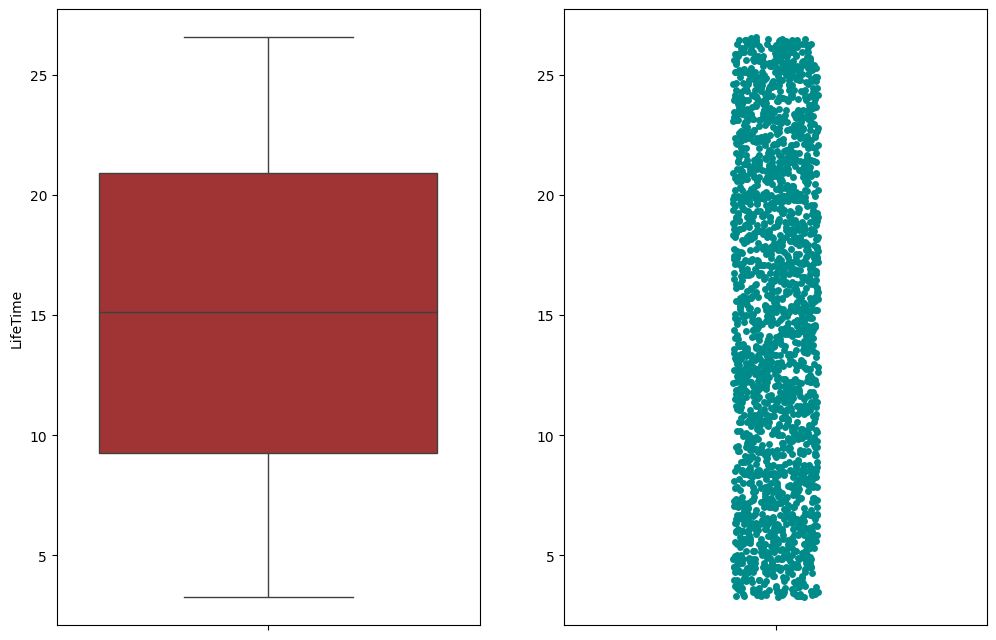

In [ ]:
plot_num(people, 'LifeTime')

In [ ]:
people.columns

Index(['ID', 'Year_Birth', 'Education', 'Income', 'Dt_Customer', 'Recency',
       'Complain', 'Marital_Status_Divorced', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow', 'ChildrenHome',
       'LifeTime'],
      dtype='object')

##### Recency

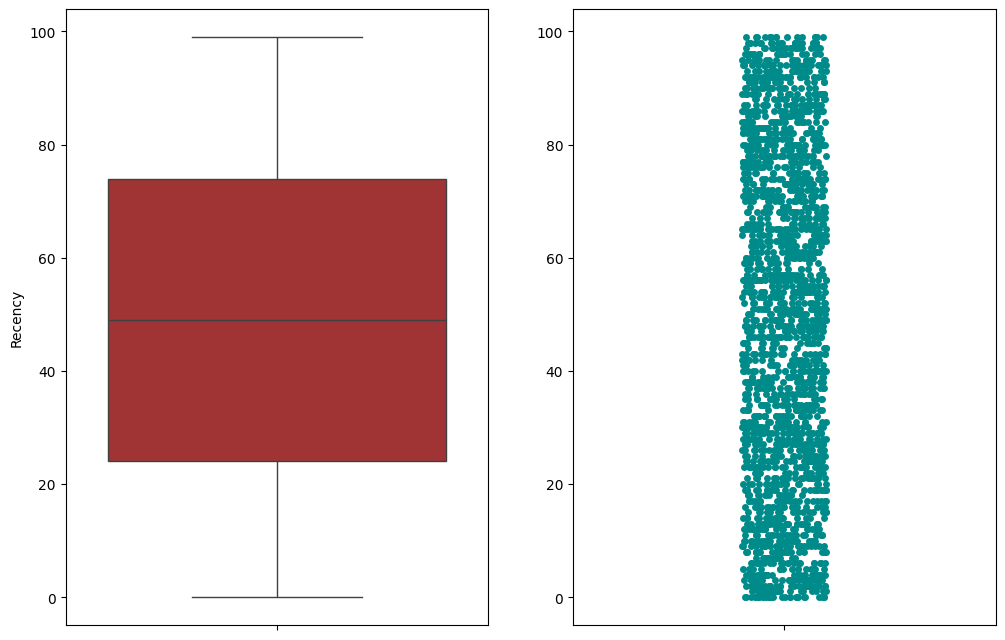

In [ ]:
plot_num(people, 'Recency')

##### Complain

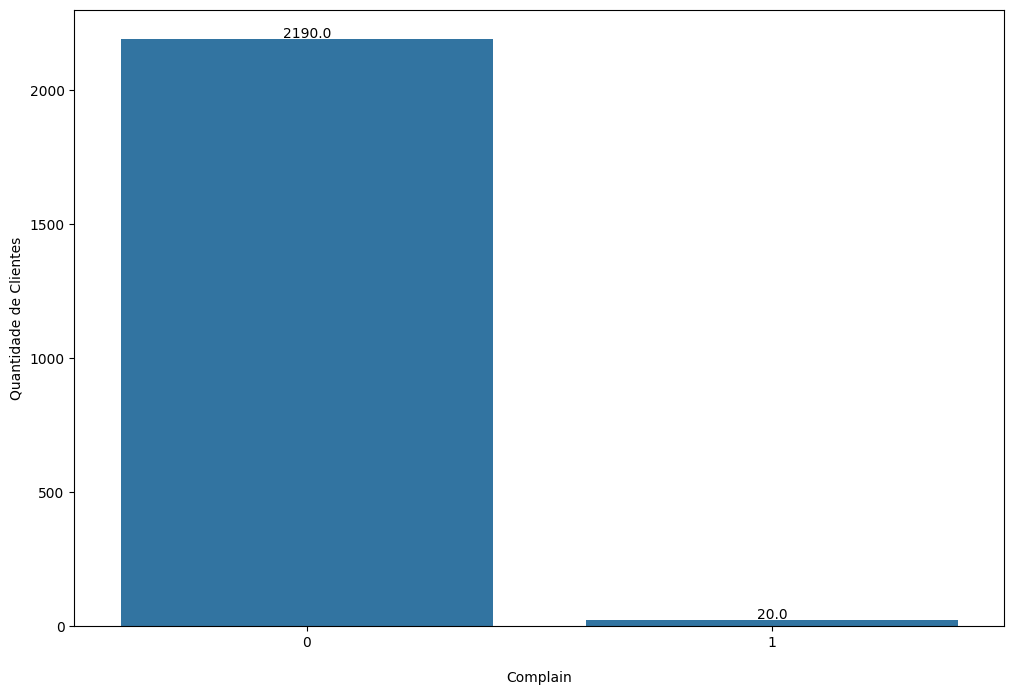

In [ ]:
plot_cat(people, 'Complain')

In [ ]:
# como solo 1% de las personas han reclamado vamos eliminar esta variavel
people.drop(columns=['Complain'], inplace=True)

In [ ]:
people.head()

,ID,Year_Birth,Education,Income,Dt_Customer,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime
0,5524,1957,2,58138,2012-09-04,58,0,1,0,0,0,25.366667
1,2174,1954,2,46344,2014-03-08,38,0,1,0,0,2,7.033333
2,4141,1965,2,71613,2013-08-21,26,0,0,1,0,0,13.666667
3,6182,1984,2,26646,2014-02-10,26,0,0,1,0,1,7.900000
4,5324,1981,4,58293,2014-01-19,94,0,0,1,0,1,8.633333


In [ ]:
people.drop(columns=['Dt_Customer'], inplace=True)

In [ ]:
people.head()

,ID,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime
0,5524,1957,2,58138,58,0,1,0,0,0,25.366667
1,2174,1954,2,46344,38,0,1,0,0,2,7.033333
2,4141,1965,2,71613,26,0,0,1,0,0,13.666667
3,6182,1984,2,26646,26,0,0,1,0,1,7.900000
4,5324,1981,4,58293,94,0,0,1,0,1,8.633333


#### Products

In [ ]:
products = df[['ID','MntWines','MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

In [ ]:
products.head()

,ID,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,5524,635,88,546,172,88,88
1,2174,11,1,6,2,1,6
2,4141,426,49,127,111,21,42
3,6182,11,4,20,10,3,5
4,5324,173,43,118,46,27,15


In [ ]:
show_null(products)

,#,% null,type
ID,0,0.0,int64
MntWines,0,0.0,int64
MntFruits,0,0.0,int64
MntMeatProducts,0,0.0,int64
MntFishProducts,0,0.0,int64
MntSweetProducts,0,0.0,int64
MntGoldProds,0,0.0,int64


##### MntWines

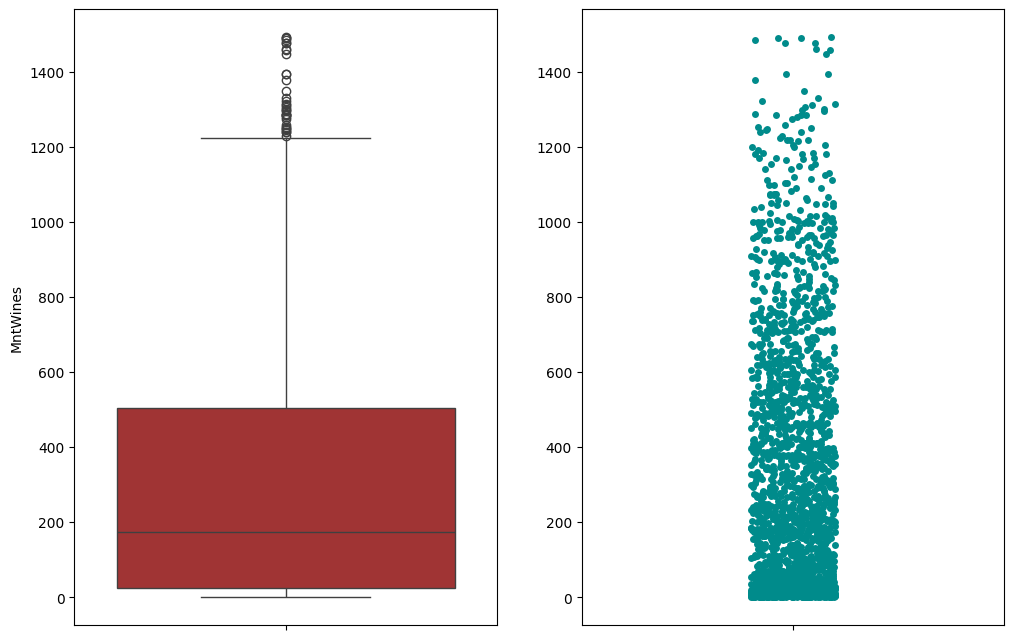

In [ ]:
plot_num(products, 'MntWines')

##### MntFruits

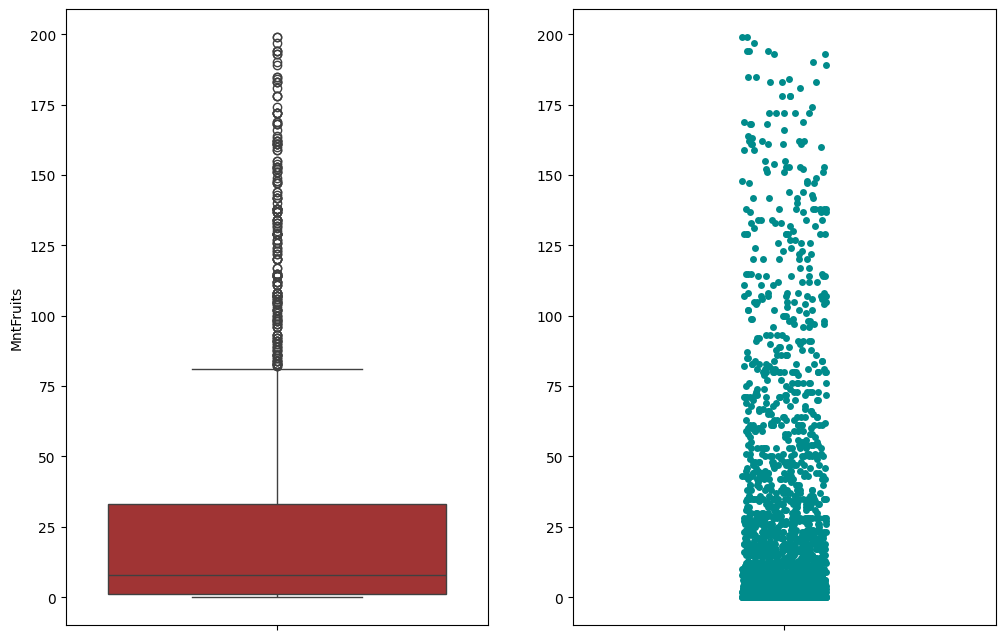

In [ ]:
plot_num(products, 'MntFruits')

##### MntMeatProducts

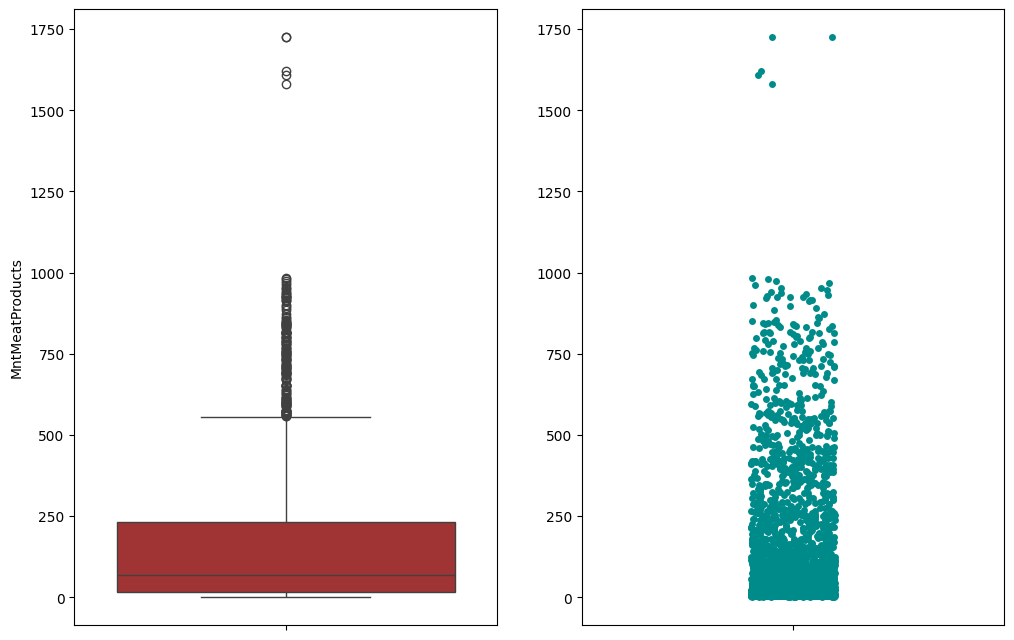

In [ ]:
plot_num(products, 'MntMeatProducts')

##### MntFishProducts

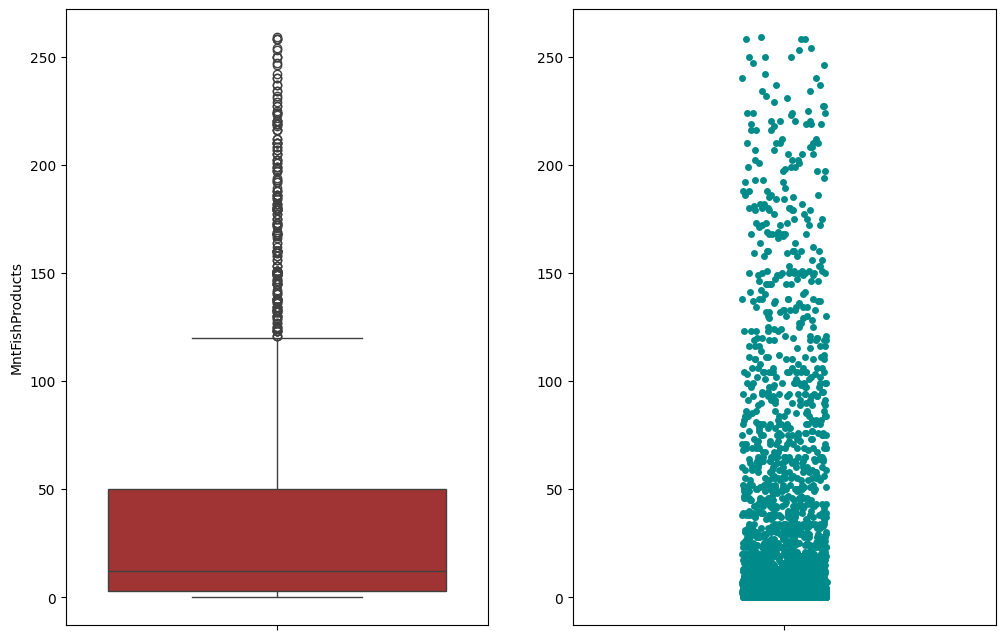

In [ ]:
plot_num(products, 'MntFishProducts')

##### MntSweetProducts

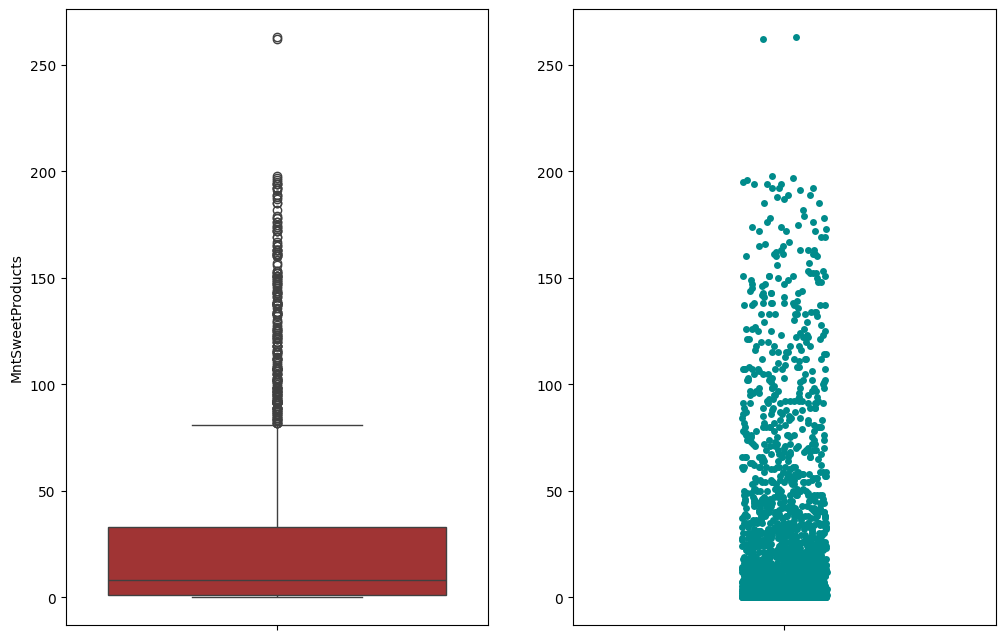

In [ ]:
plot_num(products, 'MntSweetProducts')

##### MntGoldProds

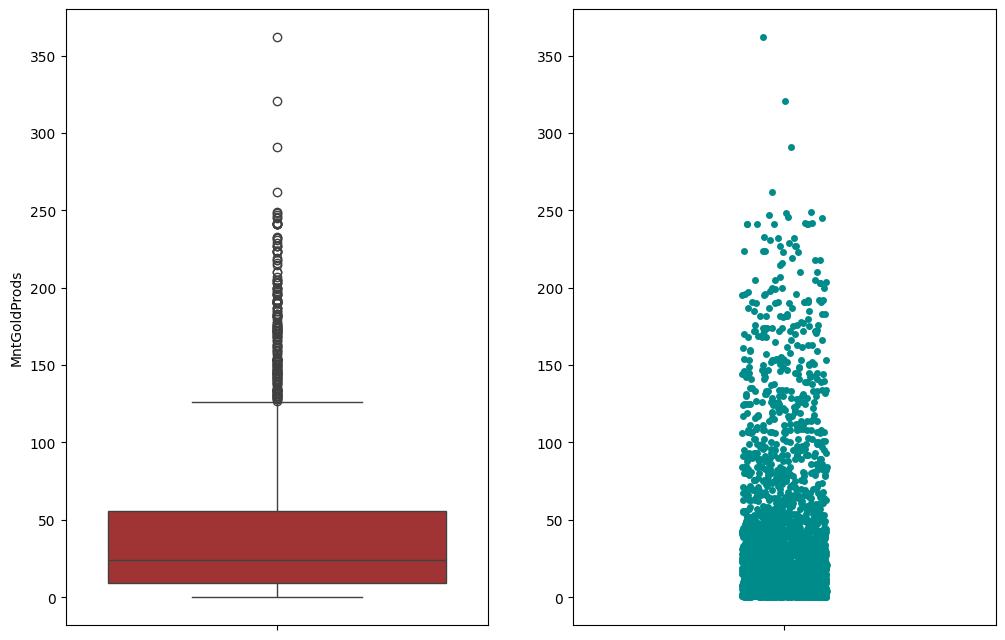

In [ ]:
plot_num(products, 'MntGoldProds')

In [ ]:
products['TotalAmountSpent'] = products.MntFishProducts + products.MntFruits + products.MntGoldProds \
+ products.MntMeatProducts + products.MntSweetProducts + products.MntWines

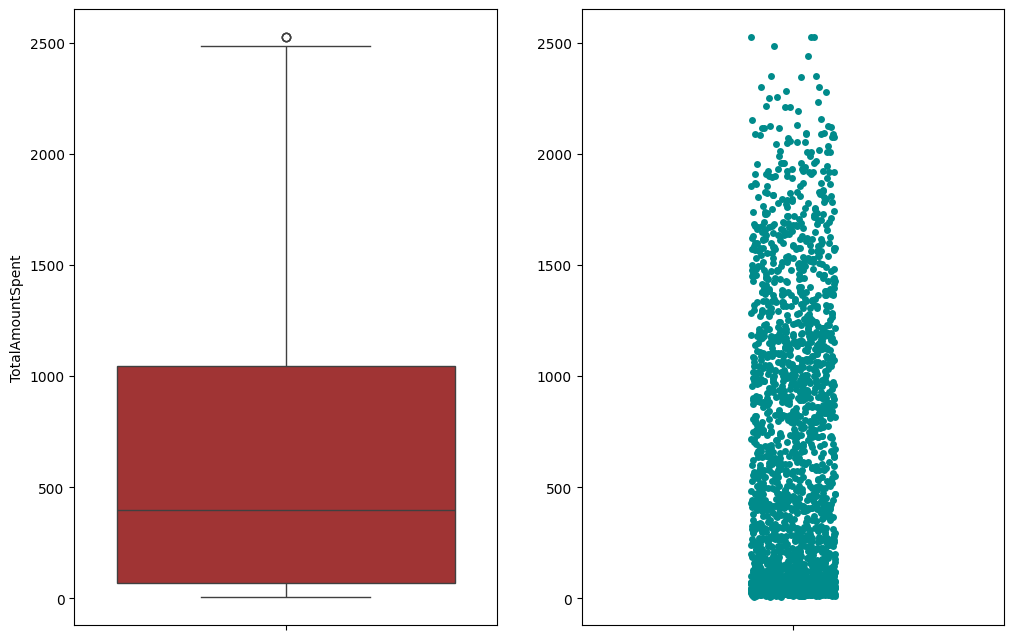

In [ ]:
plot_num(products, 'TotalAmountSpent')

In [ ]:
products.MntFishProducts = products.MntFishProducts/products['TotalAmountSpent']
products.MntFruits = products.MntFruits/products['TotalAmountSpent']
products.MntGoldProds = products.MntGoldProds/products['TotalAmountSpent']
products.MntMeatProducts = products.MntMeatProducts/products['TotalAmountSpent']
products.MntSweetProducts = products.MntSweetProducts/products['TotalAmountSpent']
products.MntWines = products.MntWines/products['TotalAmountSpent']

In [ ]:
products.describe()

,ID,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalAmountSpent
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,0.458481,0.049505,0.249508,0.071532,0.050777,0.120196,605.798214
std,3246.662198,0.228411,0.055867,0.126633,0.077909,0.061184,0.108988,602.249288
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,2828.250000,0.289506,0.008924,0.156250,0.012571,0.008621,0.038095,68.750000
50%,5458.500000,0.457482,0.029840,0.233447,0.048193,0.033333,0.086294,396.000000
75%,8427.750000,0.639143,0.070237,0.328227,0.104703,0.070411,0.169768,1045.500000
max,11191.000000,0.963303,0.445545,0.997110,0.590909,0.945848,0.894150,2525.000000


In [ ]:
products.head()

,ID,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalAmountSpent
0,5524,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,1617
1,2174,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,27
2,4141,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,776
3,6182,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,53
4,5324,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,422


#### Promotion

In [ ]:
promotion = df[['ID','AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
                'AcceptedCmp5', 'Response']]

In [ ]:
promotion.head()

,ID,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,5524,0,0,0,0,0,1
1,2174,0,0,0,0,0,0
2,4141,0,0,0,0,0,0
3,6182,0,0,0,0,0,0
4,5324,0,0,0,0,0,0


In [ ]:
show_null(promotion)

,#,% null,type
ID,0,0.0,int64
AcceptedCmp1,0,0.0,int64
AcceptedCmp2,0,0.0,int64
AcceptedCmp3,0,0.0,int64
AcceptedCmp4,0,0.0,int64
AcceptedCmp5,0,0.0,int64
Response,0,0.0,int64


In [ ]:
promotion.describe()

,ID,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107
std,3246.662198,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
promotion['AcceptedCmp'] = promotion.AcceptedCmp1 + promotion.AcceptedCmp2 + promotion.AcceptedCmp3 + promotion.AcceptedCmp4 + \
promotion.AcceptedCmp5 + promotion.Response

In [ ]:
promotion['AcceptedCmp'].describe()

,AcceptedCmp
count,2240.000000
mean,0.446875
std,0.890543
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,5.000000


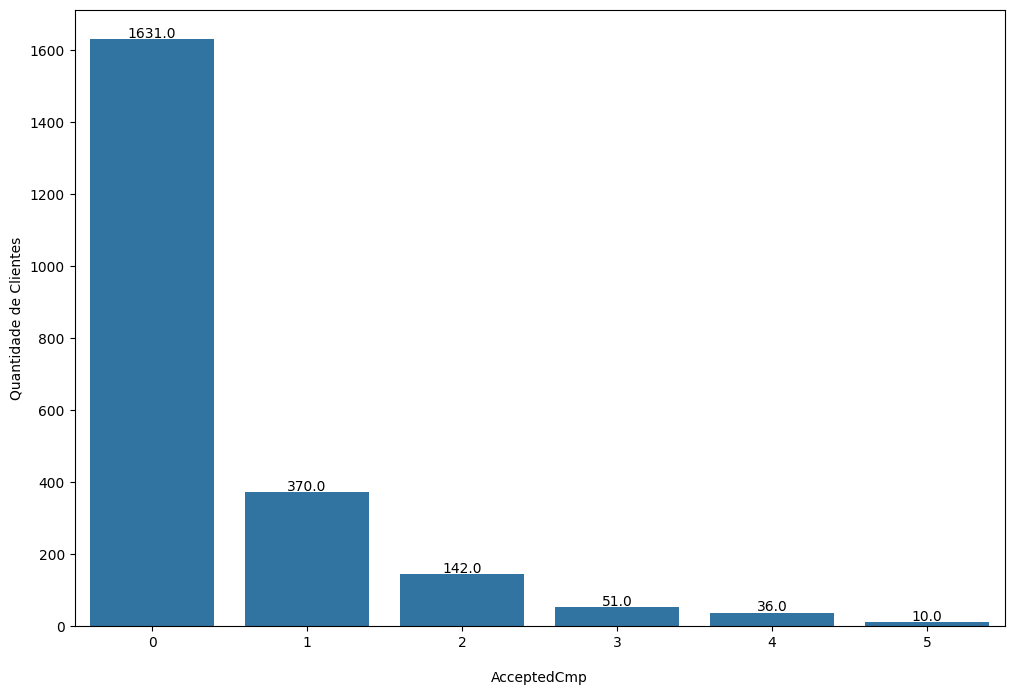

In [ ]:
plot_cat(promotion, 'AcceptedCmp')

In [ ]:
promotion = promotion[['ID', 'AcceptedCmp']]

In [ ]:
promotion.head()

,ID,AcceptedCmp
0,5524,1
1,2174,0
2,4141,0
3,6182,0
4,5324,0


#### Place

In [ ]:
place = df[['ID','NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth']]

In [ ]:
place.head()

,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
0,5524,8,10,4,3,7
1,2174,1,1,2,2,5
2,4141,8,2,10,1,4
3,6182,2,0,4,2,6
4,5324,5,3,6,5,5


In [ ]:
show_null(place)

,#,% null,type
ID,0,0.0,int64
NumWebPurchases,0,0.0,int64
NumCatalogPurchases,0,0.0,int64
NumStorePurchases,0,0.0,int64
NumDealsPurchases,0,0.0,int64
NumWebVisitsMonth,0,0.0,int64


In [ ]:
place['TotalPurchases'] = place.NumWebPurchases + place.NumCatalogPurchases + place.NumStorePurchases

In [ ]:
place.describe()

,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,4.084821,2.662054,5.790179,2.325000,5.316518,12.537054
std,3246.662198,2.778714,2.923101,3.250958,1.932238,2.426645,7.205741
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,2.000000,0.000000,3.000000,1.000000,3.000000,6.000000
50%,5458.500000,4.000000,2.000000,5.000000,2.000000,6.000000,12.000000
75%,8427.750000,6.000000,4.000000,8.000000,3.000000,7.000000,18.000000
max,11191.000000,27.000000,28.000000,13.000000,15.000000,20.000000,32.000000


In [ ]:
place[place.TotalPurchases == 0]

,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
655,5555,0,0,0,0,0,0
981,3955,0,0,0,0,14,0
1245,6862,0,0,0,15,20,0
1524,11110,0,0,0,0,14,0
1846,9931,0,0,0,15,19,0
2132,11181,0,0,0,0,0,0


In [ ]:
place = place[place['TotalPurchases']>0]

In [ ]:
place['NumWebPurchases'] = place['NumWebPurchases']/place['TotalPurchases']
place['NumCatalogPurchases'] = place['NumCatalogPurchases']/place['TotalPurchases']
place['NumStorePurchases'] = place['NumStorePurchases']/place['TotalPurchases']
place['NumDealsPurchases'] = place['NumDealsPurchases']/place['TotalPurchases']

In [ ]:
place.describe()

,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
count,2234.000000,2234.000000,2234.000000,2234.000000,2234.000000,2234.000000,2234.000000
mean,5585.427037,0.329874,0.164809,0.505317,0.247963,5.300806,12.570725
std,3245.168172,0.121858,0.140668,0.149485,0.356679,2.372957,7.186011
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2817.750000,0.250000,0.000000,0.401852,0.083333,3.000000,6.000000
50%,5453.500000,0.333333,0.150000,0.500000,0.200000,6.000000,12.000000
75%,8419.500000,0.400000,0.250000,0.600000,0.333333,7.000000,18.000000
max,11191.000000,1.000000,1.000000,1.000000,15.000000,20.000000,32.000000


In [ ]:
place[place.NumDealsPurchases > 1]

,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
1042,10749,0.0,1.0,0.0,15.0,19,1


In [ ]:
place = place[place['NumDealsPurchases']<=1]

##### NumWebPurchases

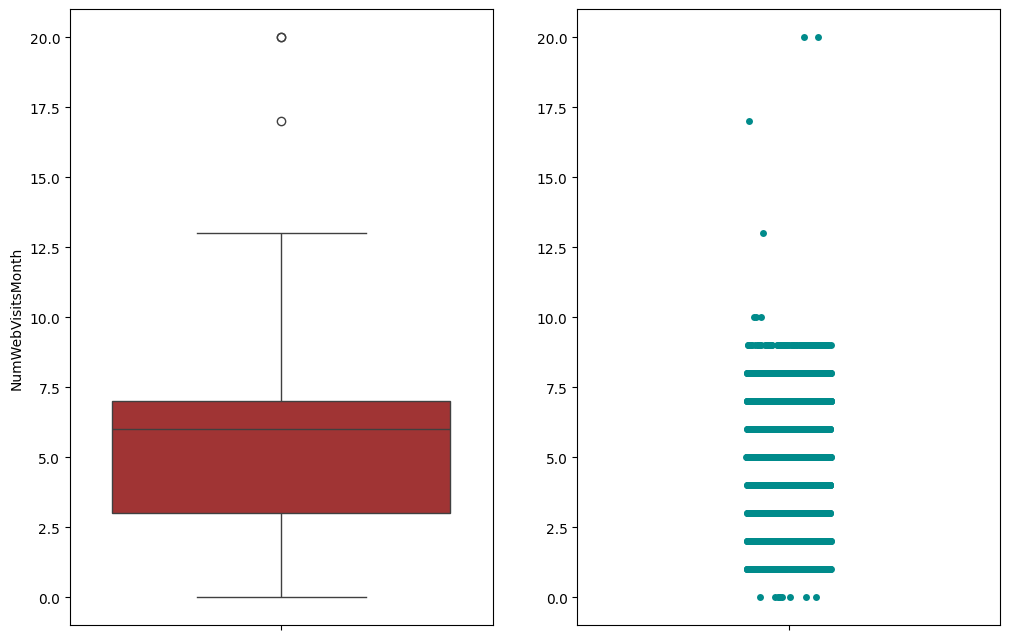

In [ ]:
plot_num(place, 'NumWebVisitsMonth')

### Juntando Dados

In [ ]:
df_lista = [people, products, promotion, place]

In [ ]:
df_final = reduce(lambda df1, df2: pd.merge(df1, df2, on='ID'), df_lista)

In [ ]:
df_final.shape

(2203, 25)

In [ ]:
df_final.columns

Index(['ID', 'Year_Birth', 'Education', 'Income', 'Recency',
       'Marital_Status_Divorced', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow', 'ChildrenHome',
       'LifeTime', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'TotalAmountSpent', 'AcceptedCmp', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
       'NumWebVisitsMonth', 'TotalPurchases'],
      dtype='object')

In [ ]:
df_final.drop(columns=['ID'], inplace=True)

### Normalização

procurar o texto do pdf para esta parte

In [ ]:
def scaler(df):
    df2 = df.copy()
    for column in df2:
        minimo = df2[column].min()
        maximo = df2[column].max()
        df2[column] = (df[column] - minimo)/(maximo - minimo)
    return df2

In [ ]:
scaled_df = scaler(df_final)

In [ ]:
scaled_df.describe()

,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime,...,MntSweetProducts,MntGoldProds,TotalAmountSpent,AcceptedCmp,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
count,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,...,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000
mean,0.516179,0.615070,0.309517,0.494858,0.103495,0.214707,0.647299,0.034498,0.316689,0.506590,...,0.053607,0.134151,0.238604,0.089877,0.330002,0.164580,0.505419,0.241032,0.265138,0.374255
std,0.208790,0.251205,0.132629,0.292626,0.304674,0.410712,0.477919,0.182547,0.249584,0.289392,...,0.064434,0.121894,0.239412,0.178555,0.120862,0.139301,0.148665,0.172198,0.117599,0.231731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.339286,0.500000,0.205796,0.242424,0.000000,0.000000,0.000000,0.000000,0.000000,0.258941,...,0.009126,0.042521,0.024235,0.000000,0.250000,0.000000,0.400000,0.083333,0.150000,0.161290
50%,0.535714,0.500000,0.305883,0.494949,0.000000,0.000000,1.000000,0.000000,0.333333,0.509299,...,0.034950,0.094632,0.154946,0.000000,0.333333,0.150000,0.500000,0.200000,0.300000,0.354839
75%,0.660714,0.750000,0.412801,0.747475,0.000000,0.000000,1.000000,0.000000,0.333333,0.756795,...,0.074329,0.189881,0.413190,0.200000,0.400000,0.250000,0.600000,0.333333,0.350000,0.580645
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Método de Elbow

vamos calculat a o numero de Clusters

In [ ]:
inertia = []
num_clusters = range(1, 14)

for k in num_clusters:
    Model = KMeans(n_clusters=k)
    Model.fit(scaled_df)
    inertia.append(Model.inertia_)

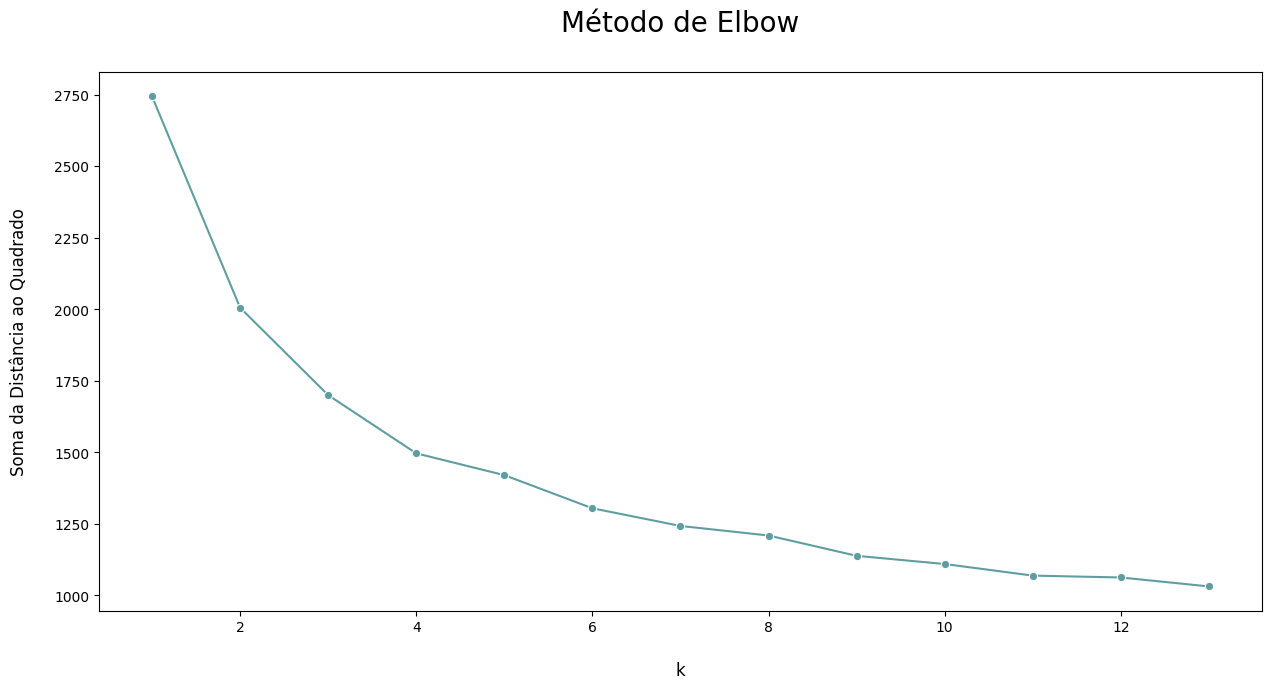

In [ ]:
plt.figure(figsize=(15,7))
sns.lineplot(x=num_clusters, y=inertia, color='cadetblue', marker='o')
plt.xlabel('\nk', size=12)
plt.ylabel('Soma da Distância ao Quadrado\n', size=12)
plt.title('Método de Elbow\n', size=20)
plt.show()

El numero de clousters es 4.

### Alocação de Pesos

In [ ]:
scaled_df.columns

Index(['Year_Birth', 'Education', 'Income', 'Recency',
       'Marital_Status_Divorced', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow', 'ChildrenHome',
       'LifeTime', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'TotalAmountSpent', 'AcceptedCmp', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
       'NumWebVisitsMonth', 'TotalPurchases'],
      dtype='object')

In [ ]:
scaled_df.TotalAmountSpent = 8*scaled_df.TotalAmountSpent
scaled_df.TotalPurchases = 6*scaled_df.TotalPurchases
scaled_df.Recency = 4*scaled_df.Recency
scaled_df.NumWebVisitsMonth = 4*scaled_df.NumWebVisitsMonth
scaled_df.Income = 4*scaled_df.Income
scaled_df.LifeTime = 4*scaled_df.LifeTime
scaled_df.Year_Birth = 2*scaled_df.Year_Birth
scaled_df.ChildrenHome = 2*scaled_df.ChildrenHome
scaled_df.Education = 2*scaled_df.Education

In [ ]:
scaled_df.describe()

,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime,...,MntSweetProducts,MntGoldProds,TotalAmountSpent,AcceptedCmp,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
count,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,...,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000,2203.000000
mean,1.032358,1.230141,1.238068,1.979431,0.103495,0.214707,0.647299,0.034498,0.633379,2.026362,...,0.053607,0.134151,1.908833,0.089877,0.330002,0.164580,0.505419,0.241032,1.060554,2.245530
std,0.417580,0.502410,0.530515,1.170504,0.304674,0.410712,0.477919,0.182547,0.499168,1.157569,...,0.064434,0.121894,1.915298,0.178555,0.120862,0.139301,0.148665,0.172198,0.470396,1.390384
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.678571,1.000000,0.823182,0.969697,0.000000,0.000000,0.000000,0.000000,0.000000,1.035765,...,0.009126,0.042521,0.193882,0.000000,0.250000,0.000000,0.400000,0.083333,0.600000,0.967742
50%,1.071429,1.000000,1.223532,1.979798,0.000000,0.000000,1.000000,0.000000,0.666667,2.037196,...,0.034950,0.094632,1.239571,0.000000,0.333333,0.150000,0.500000,0.200000,1.200000,2.129032
75%,1.321429,1.500000,1.651204,2.989899,0.000000,0.000000,1.000000,0.000000,0.666667,3.027182,...,0.074329,0.189881,3.305522,0.200000,0.400000,0.250000,0.600000,0.333333,1.400000,3.483871
max,2.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2.000000,4.000000,...,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,6.000000


### Kmeans

In [ ]:
Model = KMeans(n_clusters=4)

In [ ]:
clusters = Model.fit_predict(scaled_df)

In [ ]:
clusters

array([1, 2, 3, ..., 3, 3, 2], dtype=int32)

In [ ]:
df_final['cluster'] = clusters

In [ ]:
df_final

,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime,...,MntGoldProds,TotalAmountSpent,AcceptedCmp,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,cluster
0,1957,2,58138,58,0,1,0,0,0,25.366667,...,0.054422,1617,1,0.363636,0.454545,0.181818,0.136364,7,22,1
1,1954,2,46344,38,0,1,0,0,2,7.033333,...,0.222222,27,0,0.250000,0.250000,0.500000,0.500000,5,4,2
2,1965,2,71613,26,0,0,1,0,0,13.666667,...,0.054124,776,0,0.400000,0.100000,0.500000,0.050000,4,20,3
3,1984,2,26646,26,0,0,1,0,1,7.900000,...,0.094340,53,0,0.333333,0.000000,0.666667,0.333333,6,6,2
4,1981,4,58293,94,0,0,1,0,1,8.633333,...,0.035545,422,0,0.357143,0.214286,0.428571,0.357143,5,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198,1967,2,61223,46,0,0,1,0,1,15.966667,...,0.184191,1341,0,0.562500,0.187500,0.250000,0.125000,5,16,1
2199,1946,4,64014,56,0,0,1,0,3,3.900000,...,0.018018,444,1,0.533333,0.133333,0.333333,0.466667,7,15,3
2200,1981,2,56981,91,1,0,0,0,0,8.433333,...,0.019339,1241,1,0.111111,0.166667,0.722222,0.055556,6,18,3
2201,1956,3,69245,8,0,0,1,0,1,8.466667,...,0.072361,843,0,0.285714,0.238095,0.476190,0.095238,3,21,3


#### Salvando o modelo

In [ ]:
# save the model to disk
filename = 'modelo_finalizado.sav'
pickle.dump(Model, open(filename, 'wb'))

In [ ]:
# load the model from disk
Model = pickle.load(open(filename, 'rb'))

### Análise dos Clusters

In [ ]:
df_final.cluster.value_counts()

,count
cluster,
3,629
2,585
0,570
1,419


In [ ]:
df_final.groupby('cluster').mean()

,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime,...,MntSweetProducts,MntGoldProds,TotalAmountSpent,AcceptedCmp,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
cluster,,,,,,,,,,,,,,,,,,,,,
0,1970.128070,2.315789,36516.084211,74.600000,0.103509,0.217544,0.657895,0.021053,1.277193,14.452573,...,0.057562,0.165391,130.656140,0.121053,0.349081,0.089225,0.561694,0.346385,6.373684,6.719298
1,1968.761337,2.596659,77120.233890,50.840095,0.102625,0.250597,0.613365,0.033413,0.295943,16.952267,...,0.042874,0.050902,1606.073986,1.248210,0.276666,0.308068,0.415265,0.082961,3.463007,20.317422
2,1971.194872,2.389744,36543.225641,23.517949,0.095726,0.223932,0.651282,0.029060,1.217094,14.069915,...,0.053052,0.165162,127.514530,0.263248,0.346918,0.081640,0.571443,0.336383,6.364103,6.605128
3,1965.766296,2.565978,63513.248013,48.243243,0.111288,0.179650,0.656598,0.052464,0.841017,15.306571,...,0.047524,0.082723,824.573927,0.387917,0.332508,0.214422,0.453070,0.162176,4.570747,18.370429


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df_final.groupby('cluster').mean()

,Year_Birth,Education,Income,Recency,Marital_Status_Divorced,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,ChildrenHome,LifeTime,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalAmountSpent,AcceptedCmp,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
cluster,,,,,,,,,,,,,,,,,,,,,,,,
0,1970.128070,2.315789,36516.084211,74.600000,0.103509,0.217544,0.657895,0.021053,1.277193,14.452573,0.397129,0.054355,0.246689,0.078875,0.057562,0.165391,130.656140,0.121053,0.349081,0.089225,0.561694,0.346385,6.373684,6.719298
1,1968.761337,2.596659,77120.233890,50.840095,0.102625,0.250597,0.613365,0.033413,0.295943,16.952267,0.500193,0.040271,0.307128,0.058632,0.042874,0.050902,1606.073986,1.248210,0.276666,0.308068,0.415265,0.082961,3.463007,20.317422
2,1971.194872,2.389744,36543.225641,23.517949,0.095726,0.223932,0.651282,0.029060,1.217094,14.069915,0.420232,0.054160,0.225555,0.081840,0.053052,0.165162,127.514530,0.263248,0.346918,0.081640,0.571443,0.336383,6.364103,6.605128
3,1965.766296,2.565978,63513.248013,48.243243,0.111288,0.179650,0.656598,0.052464,0.841017,15.306571,0.525783,0.045858,0.234638,0.063475,0.047524,0.082723,824.573927,0.387917,0.332508,0.214422,0.453070,0.162176,4.570747,18.370429


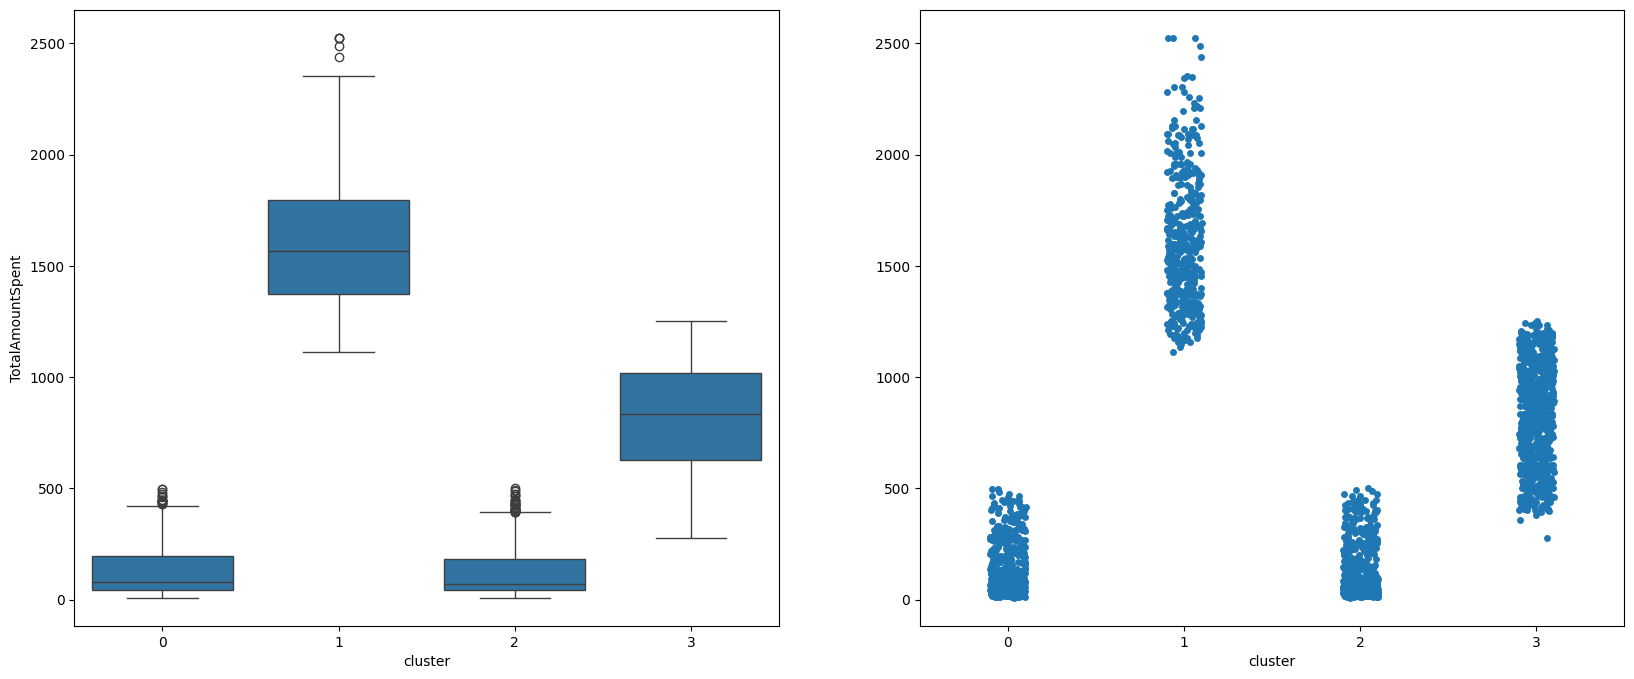

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='TotalAmountSpent', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('TotalAmountSpent')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='TotalAmountSpent', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

El clúster 1 representa a los clientes con el gasto total más alto, mientras que los clústeres 0 y 2 tienen clientes con el gasto más bajo. El clúster 3 posee un perfil de gasto intermedio.

Este análisis permite identificar qué grupos de clientes son los más valiosos en términos de ingresos (clúster 1) y cuáles pueden necesitar estrategias para aumentar el consumo o evitar la pérdida de clientes (clústeres 0 y 2).

La presencia de valores atípicos indica clientes con un comportamiento atípico dentro de cada clúster, que podrían merecer atención individualizada.

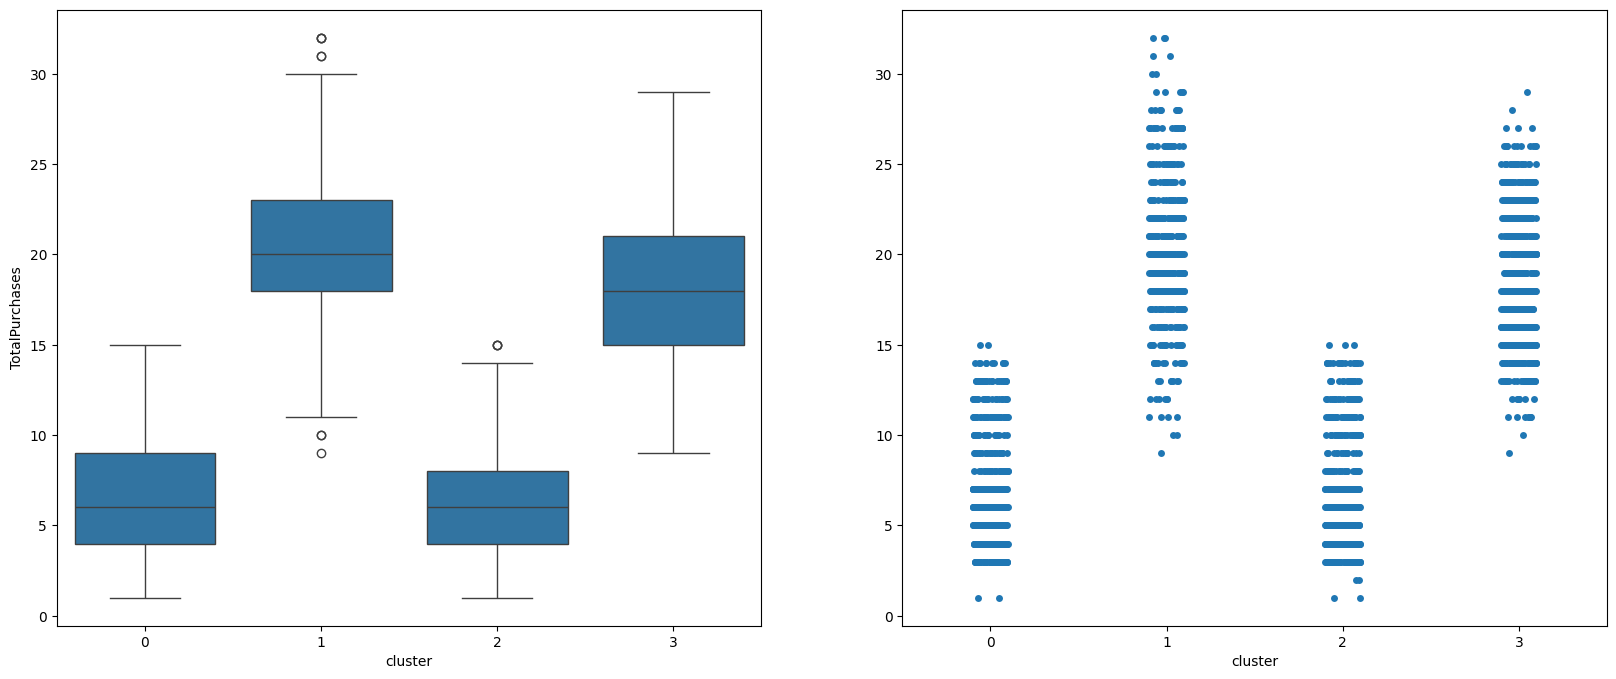

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='TotalPurchases', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('TotalPurchases')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='TotalPurchases', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

El clúster 1 debe ser priorizado en estrategias de retención y ofertas especiales, ya que concentra a los mejores clientes.

El clúster 3 puede ser objeto de acciones para aumentar el engagement y llevarlos al perfil del clúster 1.

Los clústeres 0 y 2 pueden ser trabajados con campañas de activación u ofertas básicas, o incluso ser considerados para estrategias de reducción de costos.

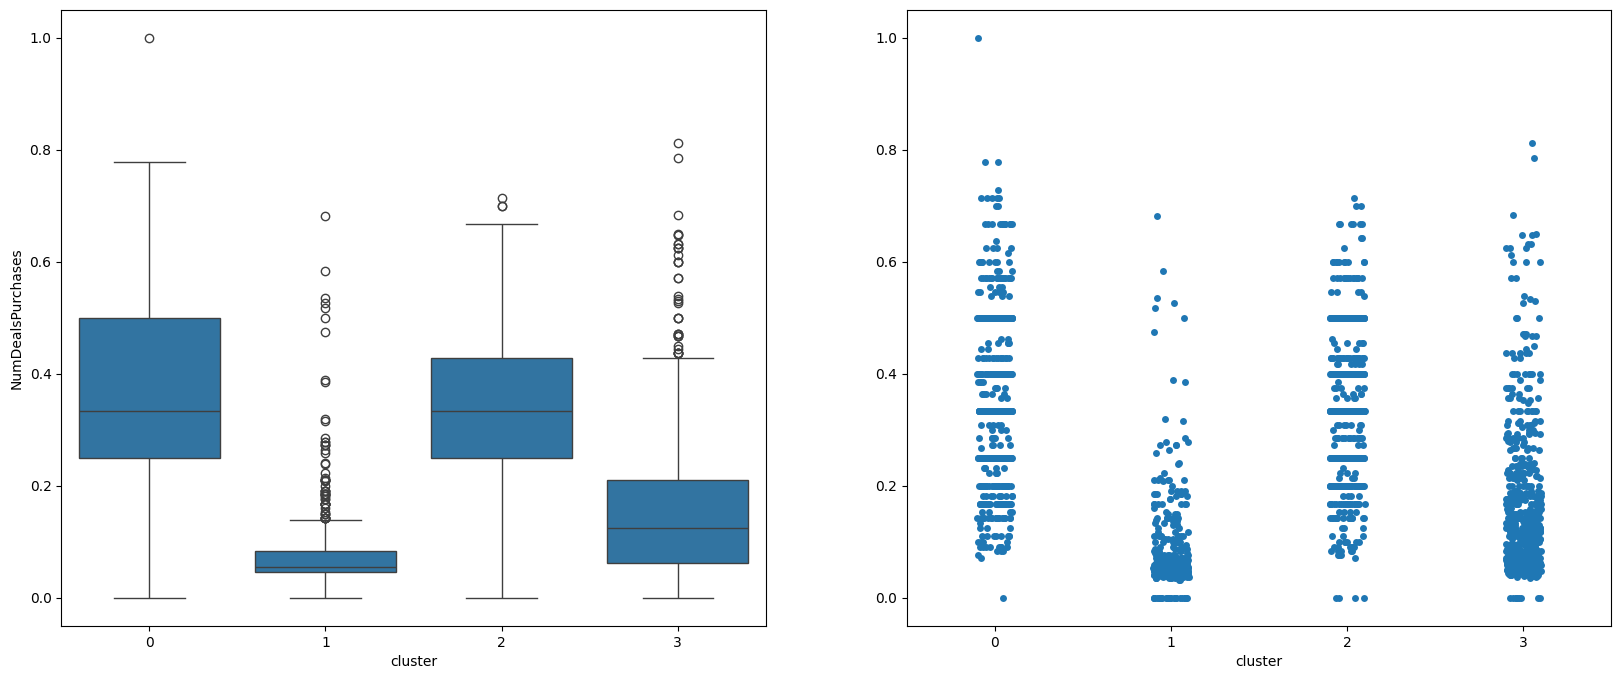

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='NumDealsPurchases', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('NumDealsPurchases')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='NumDealsPurchases', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

Clúster 1: Representa a los clientes de mayor valor, que gastan más y realizan más compras. Estos clientes deben ser priorizados en estrategias de retención, fidelización y ofertas exclusivas, ya que son los más lucrativos para el negocio.

Clúster 3: Clientes con valor intermedio en términos de gasto y número de compras. Pueden ser objeto de acciones para aumentar su engagement e incentivarlos a migrar al perfil del clúster 1, aumentando así su valor para la empresa.

Clústeres 0 y 2: Clientes con menor gasto y menor frecuencia de compras. Para estos grupos, pueden planearse campañas de activación, ofertas promocionales o estrategias de reenganche para estimular un mayor consumo. También pueden ser evaluados para optimizar costos de atención al cliente y marketing.

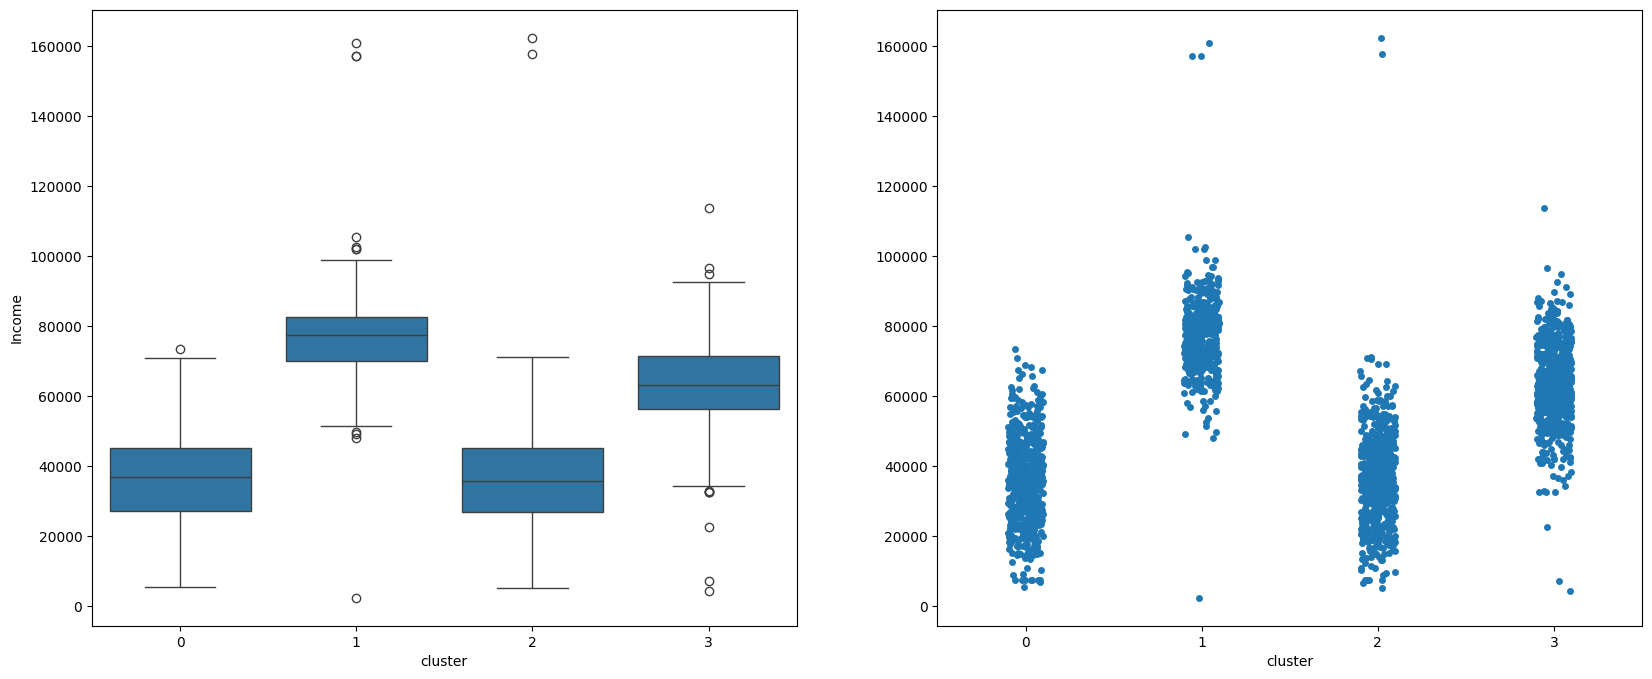

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='Income', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('Income')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='Income', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

Clúster 1
Clientes con mayor gasto total y mayor número de compras.
 Priorizar este grupo en campañas de fidelización, ofertas exclusivas y programas de beneficios, ya que son los clientes más valiosos para el negocio.

Clúster 3
Clientes con gasto y número de compras intermedios.
Desarrollar estrategias para aumentar el engagement e incentivar a estos clientes a migrar al perfil del Clúster 1, como ofertas personalizadas y comunicación dirigida.

Clústeres 0 y 2
Clientes con menor gasto total y menor frecuencia de compras.
Aplicar campañas de activación, promociones de entrada o reenganche. Evaluar el costo-beneficio de invertir en estos clientes o enfocarse en la retención de los demás clústeres.

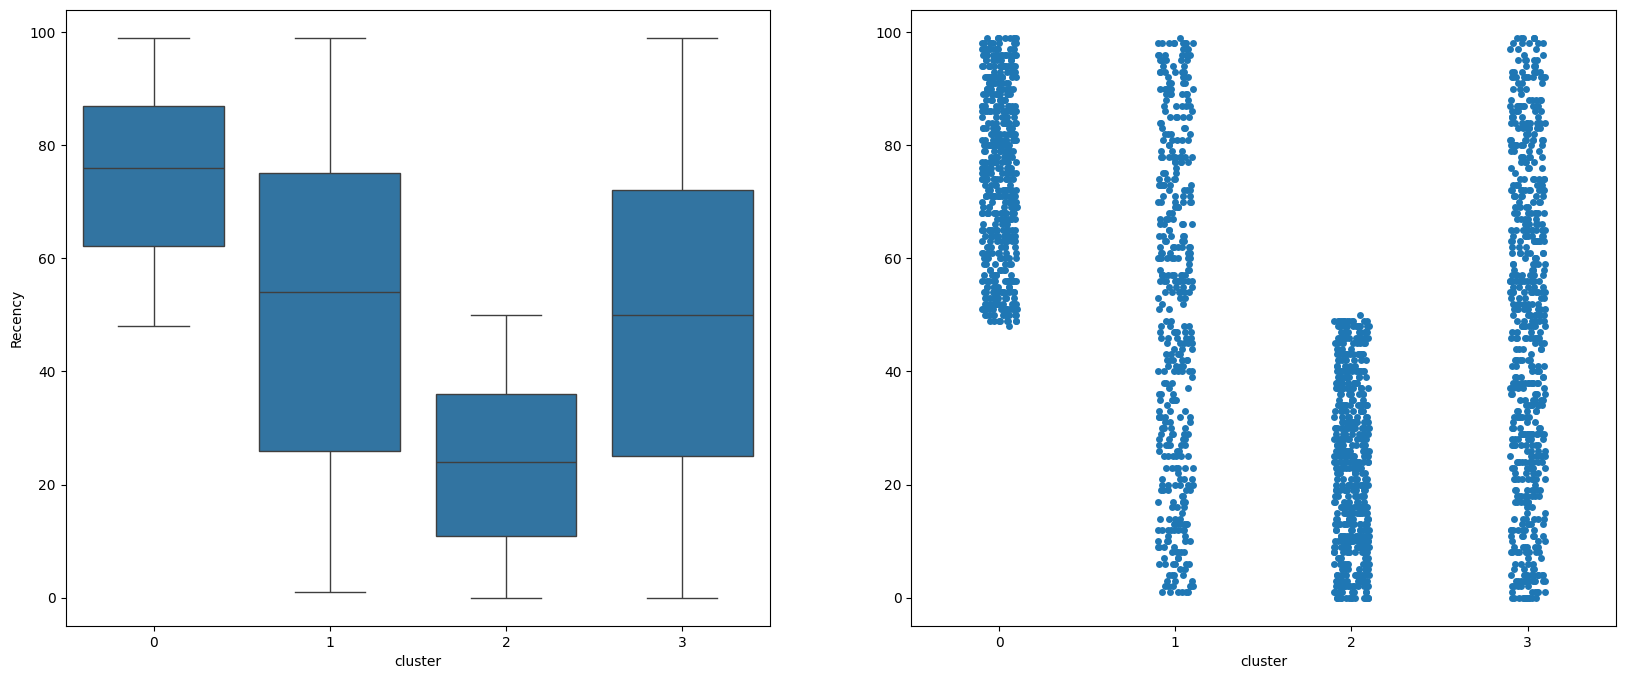

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='Recency', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('Recency')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='Recency', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

Clúster 1:
Clientes de alto valor, que gastan más y compran con mayor frecuencia, preferiblemente a precio completo. Deben ser el foco principal de estrategias de retención y fidelización, con ofertas exclusivas y programas premium.

Clúster 3:
Clientes con valor y frecuencia intermedios, que también realizan compras con descuento moderadamente. Pueden ser estimulados a aumentar el gasto y la frecuencia por medio de promociones personalizadas e incentivos para convertirse en clientes de alto valor.

Clústeres 0 y 2:
Clientes con menor gasto y frecuencia, pero que realizan más compras con descuento. Las estrategias para estos grupos pueden incluir campañas de activación, ofertas promocionales e incentivos para aumentar el engagement y el ticket promedio. También es posible evaluar el costo-beneficio de mantener esfuerzos intensivos en estos segmentos.

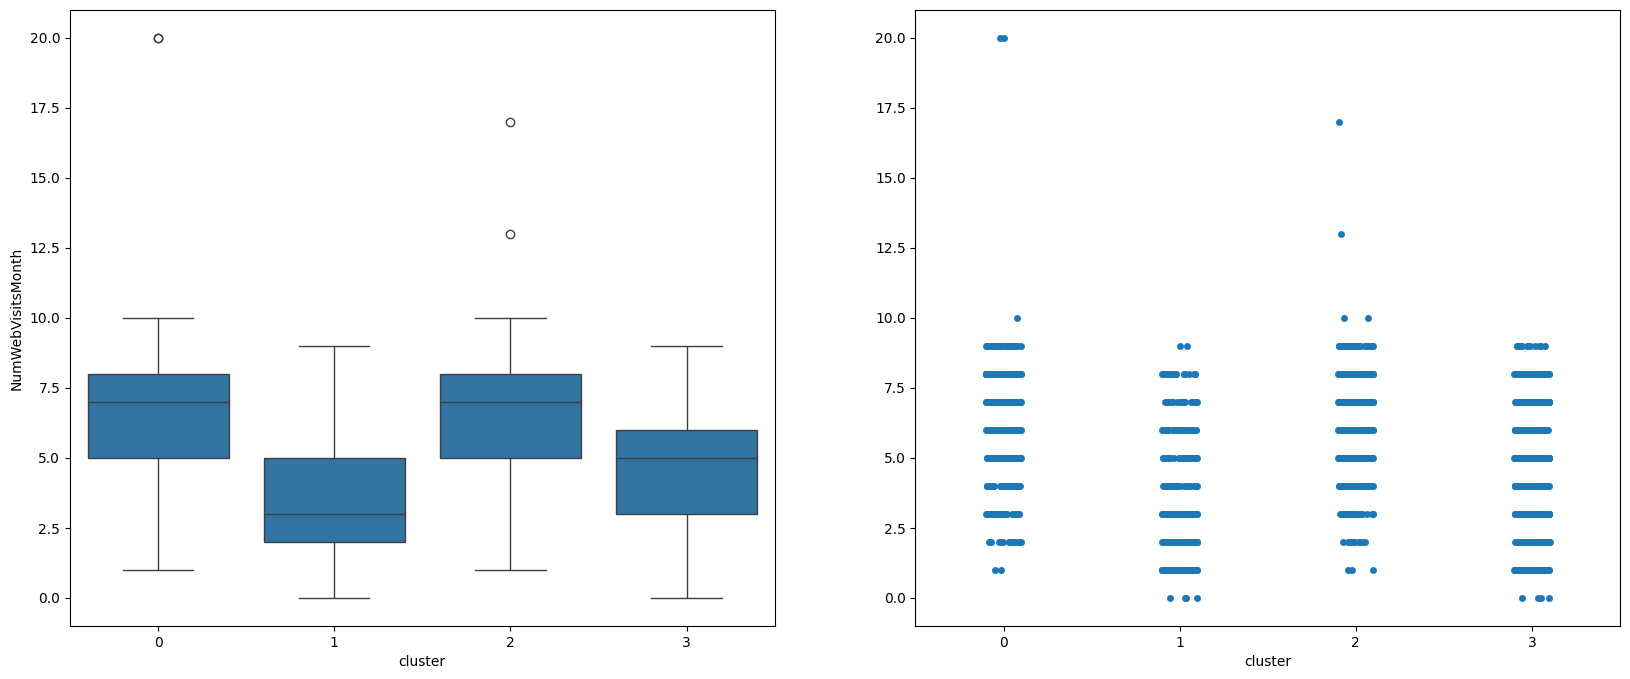

In [ ]:
fig = plt.figure(figsize=(20,8))
gs = GridSpec(1,2)
sns.boxplot(x='cluster', y='NumWebVisitsMonth', data=df_final, ax=fig.add_subplot(gs[0,0]))
plt.ylabel('NumWebVisitsMonth')
plt.xlabel('cluster')
sns.stripplot(x='cluster', y='NumWebVisitsMonth', data=df_final, ax=fig.add_subplot(gs[0,1]))
plt.ylabel(None)
plt.xlabel('cluster')
plt.show()

Clúster 1 (419 clientes)   
Clientes de alto valor con gasto total elevado (entre 1100-1800€) y alto número de compras (18-23 compras en promedio).     
Comportamiento: Realizan pocas compras con descuento (mediana cercana a 0,07 o 7%).
Representan a los clientes premium que prefieren productos a precio completo. Son los más rentables por transacción y deben ser el foco de programas de fidelidad y servicios exclusivos.

Clúster 3 (629 clientes)
Clientes de valor medio con gastos entre 600-1000€ y número de compras considerable (15-21 compras).
Presentan una proporción media-baja de compras con descuento (mediana en torno a 0,15 o 15%).    
Son clientes regulares con potencial de crecimiento. Las estrategias de upselling y cross-selling pueden ser eficaces para aumentar su valor.

Clústeres 0 (570 clientes) y 2 (585 clientes)
Clientes de bajo valor con gastos totales por debajo de 400€ y pocas compras (4-8 compras).
Alta proporción de compras con descuento, especialmente en el Clúster 0 (mediana en torno a 0,35 o 35%).  
Son clientes sensibles al precio que compran principalmente cuando hay promociones. Pueden ser objeto de campañas específicas de reactivación u ofertas promocionales para aumentar la frecuencia de compra.